# Using Generative AI to explore adapting the regressor to learn the reward distribution instead of the previous method of doing so during training... aka a reward-only model by design instead of cutting the classifier head off

# AI Used: claude.ai, gpt-4o

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import json
import time
from datetime import datetime
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import your existing tools
from tools import TrainingConfig, load_multi_dataset_with_rewards_separate_stratification, load_ibw, compute_reward_with_top_features

class StratifiedRegressor(nn.Module):
    """
    Fixed regressor with MPS compatibility
    """
    def __init__(self, input_size=None, hidden_sizes=[512, 256, 128], 
                 num_classes=None, dropout_rate=0.2, use_batch_norm=True,
                 activation='relu', pretrained_backbone=None):
        super(StratifiedRegressor, self).__init__()
        
        self.num_classes = num_classes
        self.use_batch_norm = use_batch_norm
        
        # Fixed CNN backbone with MPS compatibility
        self.backbone = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Use standard global average pooling instead of AdaptiveAvgPool2d for MPS compatibility
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        backbone_output_size = 256
        
        # Determine activation function
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'elu':
            self.activation = nn.ELU(inplace=True)
        else:
            self.activation = nn.ReLU(inplace=True)
        
        # Build regression head
        layers = []
        prev_size = backbone_output_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size) if use_batch_norm else nn.Identity(),
                self.activation,
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        # Final regression output
        layers.append(nn.Linear(prev_size, 1))
        self.regressor = nn.Sequential(*layers)
        
        # Optional classification head for class prediction from reward
        if num_classes is not None:
            self.classifier = nn.Sequential(
                nn.Linear(backbone_output_size, hidden_sizes[-1] // 2),
                nn.BatchNorm1d(hidden_sizes[-1] // 2) if use_batch_norm else nn.Identity(),
                self.activation,
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_sizes[-1] // 2, num_classes)
            )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with Xavier/He initialization"""
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)
    
    def forward(self, x, return_features=False):
        """Forward pass through the network"""
        # Extract features
        features = self.backbone(x)
        features = features.view(features.size(0), -1)  # Flatten
        
        # Get regression output
        reward_pred = self.regressor(features)
        
        outputs = {'reward': reward_pred}
        
        # Get classification output if available
        if self.num_classes is not None:
            class_pred = self.classifier(features)
            outputs['class'] = class_pred
        
        if return_features:
            outputs['features'] = features
        
        return outputs


class FixedAugmentedIBWDataset(Dataset):
    """Fixed dataset class with proper error handling"""
    def __init__(self, ibw_files, labels=None, scan_indices=None,
                 compute_rewards=False, use_augmentation=False,
                 reward_weights=None):
        
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0.0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(len(ibw_files)))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.reward_weights = reward_weights
        
        # Cache for IBW data
        self.ibw_cache = {}

        if compute_rewards:
            print("Computing rewards for dataset...")
            self.labels = []
            for i, file_path in enumerate(ibw_files):
                try:
                    ibw_data = load_ibw(file_path)
                    reward = compute_reward_with_top_features(
                        ibw_data, scan_index=self.scan_indices[i], weights=self.reward_weights)
                    self.labels.append(float(reward))
                except Exception as e:
                    print(f"Error computing reward for {file_path}: {e}")
                    self.labels.append(0.0)

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            file_path = self.ibw_files[idx]

            # Load ibw data (with caching)
            if idx in self.ibw_cache:
                ibw_data = self.ibw_cache[idx]
            else:
                ibw_data = load_ibw(file_path)
                # Only cache if dataset is small to avoid memory issues
                if len(self.ibw_files) < 1000:
                    self.ibw_cache[idx] = ibw_data

            ch_names = ibw_data.channels

            # Extract the 6 channels as numpy arrays
            amp_trace = ibw_data.data[ch_names.index('Amplitude (T)')]
            amp_retrace = ibw_data.data[ch_names.index('Amplitude (RT)')]
            phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
            phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
            height_trace = ibw_data.data[ch_names.index('Height (T)')]
            height_retrace = ibw_data.data[ch_names.index('Height (RT)')]

            # Stack channels: shape (6, H, W)
            input_np = np.stack([
                amp_trace, amp_retrace,
                phase_trace, phase_retrace,
                height_trace, height_retrace
            ], axis=0).astype(np.float32)

            # Robust normalization with clipping for extreme values
            for i in range(input_np.shape[0]):
                channel = input_np[i]
                # Clip extreme outliers (beyond 3 standard deviations)
                mean_val = np.mean(channel)
                std_val = np.std(channel)
                if std_val > 1e-8:
                    channel = np.clip(channel, mean_val - 3*std_val, mean_val + 3*std_val)
                    # Normalize
                    input_np[i] = (channel - mean_val) / (std_val + 1e-8)
                else:
                    input_np[i] = channel - mean_val

            input_tensor = torch.tensor(input_np, dtype=torch.float32)
            reward = torch.tensor(float(self.labels[idx]), dtype=torch.float32)

            return input_tensor, reward

        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}: {e}")
            # Return dummy tensor with appropriate size
            dummy = torch.zeros(6, 256, 256, dtype=torch.float32)  # Match your actual data size
            return dummy, torch.tensor(0.0, dtype=torch.float32)


def regression_collate_fn(batch):
    """Fixed collate function for regression data"""
    try:
        inputs = []
        rewards = []
        
        for item in batch:
            if len(item) == 2:
                input_tensor, reward = item
                inputs.append(input_tensor)
                rewards.append(reward)
            else:
                print(f"Unexpected item format: {len(item)} elements")
                continue
        
        if len(inputs) == 0:
            raise ValueError("No valid items in batch")
        
        # Stack tensors
        inputs_batch = torch.stack(inputs)
        rewards_batch = torch.stack(rewards)
        
        return inputs_batch, rewards_batch
        
    except Exception as e:
        print(f"Error in collate function: {e}")
        raise


def validate_regressor(model, val_dataloader, device, criterion):
    """Comprehensive validation function with metrics"""
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    num_batches = 0
    
    with torch.no_grad():
        for batch_idx, (inputs, rewards) in enumerate(val_dataloader):
            try:
                # Move tensors to device
                inputs = inputs.to(device)
                rewards = rewards.to(device)
                
                # Forward pass
                outputs = model(inputs)
                reward_pred = outputs['reward'].squeeze()
                
                # Handle dimension mismatch
                if reward_pred.dim() == 0:
                    reward_pred = reward_pred.unsqueeze(0)
                if rewards.dim() == 0:
                    rewards = rewards.unsqueeze(0)
                
                # Ensure same shape
                if reward_pred.shape != rewards.shape:
                    min_len = min(len(reward_pred), len(rewards))
                    reward_pred = reward_pred[:min_len]
                    rewards = rewards[:min_len]
                
                # Calculate loss
                loss = criterion(reward_pred, rewards)
                total_loss += loss.item()
                num_batches += 1
                
                # Store predictions and targets
                all_predictions.extend(reward_pred.cpu().numpy().flatten())
                all_targets.extend(rewards.cpu().numpy().flatten())
                
            except Exception as e:
                print(f"Error in validation batch {batch_idx}: {e}")
                continue
    
    if num_batches == 0:
        print("ERROR: No validation batches processed!")
        return float('inf'), 0.0, float('inf'), float('inf')
    
    # Calculate metrics
    avg_val_loss = total_loss / num_batches
    
    try:
        r2 = r2_score(all_targets, all_predictions)
        mae = mean_absolute_error(all_targets, all_predictions)
        rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
    except Exception as e:
        print(f"Error calculating metrics: {e}")
        r2 = 0.0
        mae = float('inf')
        rmse = float('inf')
    
    return avg_val_loss, r2, mae, rmse


class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=7, min_delta=0, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1

        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False

    def save_checkpoint(self, model):
        """Saves model when validation loss decreases."""
        self.best_weights = model.state_dict().copy()


def save_model_and_config(model, config, train_history, save_dir, model_name="best_model"):
    """Save model, config, and training history"""
    os.makedirs(save_dir, exist_ok=True)
    
    # Save model state dict
    model_path = os.path.join(save_dir, f"{model_name}.pth")
    torch.save(model.state_dict(), model_path)
    
    # Save full model (for easier loading later)
    full_model_path = os.path.join(save_dir, f"{model_name}_full.pth")
    torch.save(model, full_model_path)
    
    # Save model config
    model_config = {
        'hidden_sizes': [512, 256, 128],  # You can make this configurable
        'num_classes': model.num_classes,
        'dropout_rate': 0.2,  # You can make this configurable
        'use_batch_norm': model.use_batch_norm,
        'activation': 'relu'  # You can make this configurable
    }
    config_path = os.path.join(save_dir, f"{model_name}_config.json")
    with open(config_path, 'w') as f:
        json.dump(model_config, f, indent=2)
    
    # Save training history
    history_path = os.path.join(save_dir, f"{model_name}_history.json")
    with open(history_path, 'w') as f:
        json.dump(train_history, f, indent=2)
    
    # Save training configuration
    training_config_path = os.path.join(save_dir, f"{model_name}_training_config.json")
    config_dict = {
        'base_folder': config.original_dataset['base_folder'],
        'dataset_folders': config.original_dataset['dataset_folders'],
        'reward_weights': config.augmented_dataset['reward_weights'],
        'num_classes': config.num_classes,
        'train_split_weight': config.train_split_weight,
        'training_batch_size': config.training_batch_size
    }
    with open(training_config_path, 'w') as f:
        json.dump(config_dict, f, indent=2)
    
    print(f"Model and configs saved to {save_dir}")
    print(f"Model state dict: {model_path}")
    print(f"Full model: {full_model_path}")
    print(f"Model config: {config_path}")
    print(f"Training history: {history_path}")
    print(f"Training config: {training_config_path}")


def plot_training_history(train_history, save_dir, model_name="training"):
    """Plot and save training curves"""
    if not train_history['train_loss'] or not train_history['val_loss']:
        print("No training history to plot")
        return
    
    epochs = range(1, len(train_history['train_loss']) + 1)
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss plot
    ax1.plot(epochs, train_history['train_loss'], 'b-', label='Training Loss')
    ax1.plot(epochs, train_history['val_loss'], 'r-', label='Validation Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # R² score plot
    if train_history['val_r2']:
        ax2.plot(epochs, train_history['val_r2'], 'g-', label='Validation R²')
        ax2.set_title('Validation R² Score')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('R² Score')
        ax2.legend()
        ax2.grid(True)
    
    # MAE plot
    if train_history['val_mae']:
        ax3.plot(epochs, train_history['val_mae'], 'm-', label='Validation MAE')
        ax3.set_title('Validation Mean Absolute Error')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('MAE')
        ax3.legend()
        ax3.grid(True)
    
    # RMSE plot
    if train_history['val_rmse']:
        ax4.plot(epochs, train_history['val_rmse'], 'c-', label='Validation RMSE')
        ax4.set_title('Validation Root Mean Squared Error')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('RMSE')
        ax4.legend()
        ax4.grid(True)
    
    plt.tight_layout()
    plot_path = os.path.join(save_dir, f"{model_name}_training_curves.png")
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Training curves saved to {plot_path}")


def main():
    """Complete training script with all configurations"""
    
    print("=" * 60)
    print("STRATIFIED REGRESSOR TRAINING SCRIPT")
    print("=" * 60)
    
    # Setup device with MPS compatibility
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("Using CUDA")
    elif hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("Using CPU")

    # Load configuration
    config_path = 'config.yaml'
    config = TrainingConfig.from_yaml(config_path)
    
    base_folder = config.original_dataset['base_folder']
    dataset_folders = config.original_dataset['dataset_folders']
    
    print(f"\nLoading data from: {base_folder}")
    print(f"Dataset folders: {dataset_folders}")
    
    # Load data
    all_files, all_labels, all_rewards, dataset_info = load_multi_dataset_with_rewards_separate_stratification(
        [base_folder],
        dataset_folders, 
        reward_weights=config.augmented_dataset['reward_weights'],
        labeling_method='stratified',
        num_classes=config.num_classes
    )
    
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")
    print(f"Reward stats: min={np.min(all_rewards):.4f}, max={np.max(all_rewards):.4f}, mean={np.mean(all_rewards):.4f}")
    
    # Create train/val split
    train_indices, val_indices = train_test_split(
        np.arange(len(all_files)),
        train_size=config.train_split_weight,
        stratify=all_labels,
        random_state=42
    )
    
    # Partition data
    train_files = [all_files[i] for i in train_indices]
    train_labels = [all_labels[i] for i in train_indices]
    train_rewards = [all_rewards[i] for i in train_indices]
    
    val_files = [all_files[i] for i in val_indices]
    val_labels = [all_labels[i] for i in val_indices]
    val_rewards = [all_rewards[i] for i in val_indices]
    
    print(f"\nData Split:")
    print(f"Train set: {len(train_files)} files")
    print(f"Val set: {len(val_files)} files")
    print(f"Train reward stats: min={np.min(train_rewards):.4f}, max={np.max(train_rewards):.4f}")
    print(f"Val reward stats: min={np.min(val_rewards):.4f}, max={np.max(val_rewards):.4f}")
    
    # Create datasets
    print("\nCreating datasets...")
    train_dataset = FixedAugmentedIBWDataset(
        train_files,
        train_rewards,
        list(range(len(train_files))),
        compute_rewards=False,
        use_augmentation=config.augmented_dataset['use_data_augmentation'],
        reward_weights=config.augmented_dataset['reward_weights']
    )
    
    val_dataset = FixedAugmentedIBWDataset(
        val_files,
        val_rewards,
        list(range(len(val_files))),
        compute_rewards=False,
        use_augmentation=False,
        reward_weights=config.augmented_dataset['reward_weights']
    )
    
    # Create dataloaders
    batch_size = config.training_batch_size
    train_dataloader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=regression_collate_fn,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )
    val_dataloader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=regression_collate_fn,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")
    
    # Create model
    print("\nCreating model...")
    model = StratifiedRegressor(
        hidden_sizes=[512, 256, 128],
        num_classes=None,  # Focus on regression only
        dropout_rate=0.3,
        use_batch_norm=True,
        activation='relu'
    ).to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model created: {total_params:,} total parameters, {trainable_params:,} trainable")
    
    # Setup training components
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-6)
    
    # Training configuration
    num_epochs = 1000  # Set maximum epochs
    print_every = 10
    
    # Initialize training history
    train_history = {
        'train_loss': [],
        'val_loss': [],
        'val_r2': [],
        'val_mae': [],
        'val_rmse': [],
        'learning_rate': []
    }
    
    # Create save directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"models/regressor_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\nStarting training for up to {num_epochs} epochs...")
    print(f"Results will be saved to: {save_dir}")
    print("=" * 60)
    
    best_val_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        num_batches = 0
        
        for batch_idx, (inputs, rewards) in enumerate(train_dataloader):
            inputs = inputs.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs['reward'].squeeze(), rewards)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = running_loss / num_batches
        
        # Validation phase
        val_loss, val_r2, val_mae, val_rmse = validate_regressor(model, val_dataloader, device, criterion)
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save metrics
        train_history['train_loss'].append(avg_train_loss)
        train_history['val_loss'].append(val_loss)
        train_history['val_r2'].append(val_r2)
        train_history['val_mae'].append(val_mae)
        train_history['val_rmse'].append(val_rmse)
        train_history['learning_rate'].append(current_lr)
        
        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"R²: {val_r2:.4f} | "
                  f"MAE: {val_mae:.4f} | "
                  f"LR: {current_lr:.2e} | "
                  f"Time: {elapsed:.1f}s")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_model_and_config(model, config, train_history, save_dir, "best_model")
            print(f"  ★ New best model saved! Val Loss: {val_loss:.6f}")
        
        # Early stopping check
        # if early_stopping(val_loss, model):
        #     print(f"\nEarly stopping triggered at epoch {epoch+1}")
        #     break
    
    # Final save
    save_model_and_config(model, config, train_history, save_dir, "final_model")
    
    # Plot training curves
    plot_training_history(train_history, save_dir, "training")
    
    # Final evaluation
    print("\n" + "=" * 60)
    print("TRAINING COMPLETED")
    print("=" * 60)
    
    # Load best model for final evaluation
    best_model_path = os.path.join(save_dir, "best_model.pth")
    if os.path.exists(best_model_path):
        model.load_state_dict(torch.load(best_model_path, map_location=device))
        final_val_loss, final_r2, final_mae, final_rmse = validate_regressor(model, val_dataloader, device, criterion)
        
        print(f"Final Results (Best Model):")
        print(f"  Validation Loss: {final_val_loss:.6f}")
        print(f"  R² Score: {final_r2:.4f}")
        print(f"  Mean Absolute Error: {final_mae:.4f}")
        print(f"  Root Mean Squared Error: {final_rmse:.4f}")
    
    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
    print(f"Models and results saved to: {save_dir}")


if __name__ == "__main__":
    main()

STRATIFIED REGRESSOR TRAINING SCRIPT
Using MPS (Apple Silicon)

Loading data from: exp_data2/
Dataset folders: ['read_out', 'wear_out']
Computing rewards for 100 files in exp_data2/read_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for read_out:
  Class 0: 20 samples, rewards 42.454 to 45.008
  Class 1: 20 samples, rewards 45.770 to 47.794
  Class 2: 20 samples, rewards 47.861 to 49.431
  Class 3: 20 samples, rewards 49.524 to 50.891
  Class 4: 20 samples, rewards 50.945 to 51.983
Computing rewards for 100 files in exp_data2/wear_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for wear_out:
  Class 0: 20 samples, rewards 42.204 to 45.853
  Class 1: 20 samples, rewards 45.858 to 47.713
  Class 2: 20 samples, rewards 47.808 to 49.751
  Class 3: 20 samples,

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import json
import time
from datetime import datetime
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import your existing tools
from tools import TrainingConfig, load_multi_dataset_with_rewards_separate_stratification, load_ibw, compute_reward_with_top_features

class FixedStratifiedRegressor(nn.Module):
    """
    FIXED regressor with proper architecture and target scaling
    """
    def __init__(self, input_size=None, hidden_sizes=[512, 256, 128], 
                 num_classes=None, dropout_rate=0.2, use_batch_norm=True,
                 activation='relu', target_mean=0.0, target_std=1.0):
        super(FixedStratifiedRegressor, self).__init__()
        
        self.num_classes = num_classes
        self.use_batch_norm = use_batch_norm
        
        # Store target statistics for denormalization
        self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # Fixed CNN backbone with MPS compatibility
        self.backbone = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        backbone_output_size = 256
        
        # Determine activation function
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'elu':
            self.activation = nn.ELU(inplace=True)
        else:
            self.activation = nn.ReLU(inplace=True)
        
        # Build regression head - CRITICAL: NO ACTIVATION ON FINAL LAYER
        layers = []
        prev_size = backbone_output_size
        
        for hidden_size in hidden_sizes:
            layers.extend([
                nn.Linear(prev_size, hidden_size),
                nn.BatchNorm1d(hidden_size) if use_batch_norm else nn.Identity(),
                self.activation,
                nn.Dropout(dropout_rate)
            ])
            prev_size = hidden_size
        
        # CRITICAL FIX: Final regression output with NO ACTIVATION
        layers.append(nn.Linear(prev_size, 1))
        # NO ACTIVATION HERE - this was likely your main issue
        self.regressor = nn.Sequential(*layers)
        
        # Optional classification head for class prediction from reward
        if num_classes is not None:
            self.classifier = nn.Sequential(
                nn.Linear(backbone_output_size, hidden_sizes[-1] // 2),
                nn.BatchNorm1d(hidden_sizes[-1] // 2) if use_batch_norm else nn.Identity(),
                self.activation,
                nn.Dropout(dropout_rate),
                nn.Linear(hidden_sizes[-1] // 2, num_classes)
            )
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with Xavier/He initialization"""
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)
    
    def forward(self, x, return_features=False, denormalize=True):
        """Forward pass through the network"""
        # Extract features
        features = self.backbone(x)
        features = features.view(features.size(0), -1)  # Flatten
        
        # Get regression output
        reward_pred = self.regressor(features)
        
        # CRITICAL: Denormalize predictions to original scale
        if denormalize and hasattr(self, 'target_mean') and hasattr(self, 'target_std'):
            reward_pred = reward_pred * self.target_std + self.target_mean
        
        outputs = {'reward': reward_pred}
        
        # Get classification output if available
        if self.num_classes is not None:
            class_pred = self.classifier(features)
            outputs['class'] = class_pred
        
        if return_features:
            outputs['features'] = features
        
        return outputs
    
    def update_target_stats(self, target_mean, target_std):
        """Update target statistics for proper denormalization"""
        self.target_mean = torch.tensor(target_mean, dtype=torch.float32, device=self.target_mean.device)
        self.target_std = torch.tensor(target_std, dtype=torch.float32, device=self.target_std.device)


class ImprovedIBWDataset(Dataset):
    """Improved dataset class with target normalization"""
    def __init__(self, ibw_files, labels=None, scan_indices=None,
                 compute_rewards=False, use_augmentation=False,
                 reward_weights=None, normalize_targets=True):
        
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0.0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(len(ibw_files)))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.reward_weights = reward_weights
        self.normalize_targets = normalize_targets
        
        # Cache for IBW data
        self.ibw_cache = {}

        if compute_rewards:
            print("Computing rewards for dataset...")
            self.labels = []
            for i, file_path in enumerate(ibw_files):
                try:
                    ibw_data = load_ibw(file_path)
                    reward = compute_reward_with_top_features(
                        ibw_data, scan_index=self.scan_indices[i], weights=self.reward_weights)
                    self.labels.append(float(reward))
                except Exception as e:
                    print(f"Error computing reward for {file_path}: {e}")
                    self.labels.append(0.0)
        
        # CRITICAL: Compute target statistics for normalization
        if normalize_targets and len(self.labels) > 0:
            labels_array = np.array(self.labels)
            self.target_mean = np.mean(labels_array)
            self.target_std = np.std(labels_array)
            if self.target_std < 1e-8:  # Avoid division by zero
                self.target_std = 1.0
            
            print(f"Target statistics: mean={self.target_mean:.4f}, std={self.target_std:.4f}")
        else:
            self.target_mean = 0.0
            self.target_std = 1.0

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            file_path = self.ibw_files[idx]

            # Load ibw data (with caching)
            if idx in self.ibw_cache:
                ibw_data = self.ibw_cache[idx]
            else:
                ibw_data = load_ibw(file_path)
                # Only cache if dataset is small to avoid memory issues
                if len(self.ibw_files) < 1000:
                    self.ibw_cache[idx] = ibw_data

            ch_names = ibw_data.channels

            # Extract the 6 channels as numpy arrays
            amp_trace = ibw_data.data[ch_names.index('Amplitude (T)')]
            amp_retrace = ibw_data.data[ch_names.index('Amplitude (RT)')]
            phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
            phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
            height_trace = ibw_data.data[ch_names.index('Height (T)')]
            height_retrace = ibw_data.data[ch_names.index('Height (RT)')]

            # Stack channels: shape (6, H, W)
            input_np = np.stack([
                amp_trace, amp_retrace,
                phase_trace, phase_retrace,
                height_trace, height_retrace
            ], axis=0).astype(np.float32)

            # Robust normalization with clipping for extreme values
            for i in range(input_np.shape[0]):
                channel = input_np[i]
                # Clip extreme outliers (beyond 3 standard deviations)
                mean_val = np.mean(channel)
                std_val = np.std(channel)
                if std_val > 1e-8:
                    channel = np.clip(channel, mean_val - 3*std_val, mean_val + 3*std_val)
                    # Normalize
                    input_np[i] = (channel - mean_val) / (std_val + 1e-8)
                else:
                    input_np[i] = channel - mean_val

            input_tensor = torch.tensor(input_np, dtype=torch.float32)
            
            # CRITICAL: Normalize target if enabled
            raw_reward = float(self.labels[idx])
            if self.normalize_targets:
                normalized_reward = (raw_reward - self.target_mean) / self.target_std
                reward = torch.tensor(normalized_reward, dtype=torch.float32)
            else:
                reward = torch.tensor(raw_reward, dtype=torch.float32)

            return input_tensor, reward, torch.tensor(raw_reward, dtype=torch.float32)  # Return both normalized and raw

        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}: {e}")
            # Return dummy tensor with appropriate size
            dummy = torch.zeros(6, 256, 256, dtype=torch.float32)  # Match your actual data size
            return dummy, torch.tensor(0.0, dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)


def improved_collate_fn(batch):
    """Improved collate function for regression data with raw targets"""
    try:
        inputs = []
        rewards = []
        raw_rewards = []
        
        for item in batch:
            if len(item) == 3:
                input_tensor, reward, raw_reward = item
                inputs.append(input_tensor)
                rewards.append(reward)
                raw_rewards.append(raw_reward)
            elif len(item) == 2:
                input_tensor, reward = item
                inputs.append(input_tensor)
                rewards.append(reward)
                raw_rewards.append(reward)  # Use same as normalized if no raw provided
            else:
                print(f"Unexpected item format: {len(item)} elements")
                continue
        
        if len(inputs) == 0:
            raise ValueError("No valid items in batch")
        
        # Stack tensors
        inputs_batch = torch.stack(inputs)
        rewards_batch = torch.stack(rewards)
        raw_rewards_batch = torch.stack(raw_rewards)
        
        return inputs_batch, rewards_batch, raw_rewards_batch
        
    except Exception as e:
        print(f"Error in collate function: {e}")
        raise


def validate_regressor_improved(model, val_dataloader, device, criterion, use_raw_targets=True):
    """Improved validation function with proper target handling"""
    model.eval()
    
    total_loss = 0.0
    all_predictions = []
    all_targets = []
    all_raw_targets = []
    num_batches = 0
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(val_dataloader):
            try:
                if len(batch_data) == 3:
                    inputs, rewards, raw_rewards = batch_data
                else:
                    inputs, rewards = batch_data
                    raw_rewards = rewards
                
                # Move tensors to device
                inputs = inputs.to(device)
                rewards = rewards.to(device)
                raw_rewards = raw_rewards.to(device)
                
                # Forward pass - get denormalized predictions
                outputs = model(inputs, denormalize=True)
                reward_pred = outputs['reward'].squeeze()
                
                # Handle dimension mismatch
                if reward_pred.dim() == 0:
                    reward_pred = reward_pred.unsqueeze(0)
                if raw_rewards.dim() == 0:
                    raw_rewards = raw_rewards.unsqueeze(0)
                if rewards.dim() == 0:
                    rewards = rewards.unsqueeze(0)
                
                # Ensure same shape
                min_len = min(len(reward_pred), len(rewards), len(raw_rewards))
                reward_pred = reward_pred[:min_len]
                rewards = rewards[:min_len]
                raw_rewards = raw_rewards[:min_len]
                
                # Calculate loss using normalized targets for training stability
                loss = criterion(model(inputs, denormalize=False)['reward'].squeeze()[:min_len], rewards)
                total_loss += loss.item()
                num_batches += 1
                
                # Store predictions and targets (use raw scale for metrics)
                if use_raw_targets:
                    all_predictions.extend(reward_pred.cpu().numpy().flatten())
                    all_targets.extend(raw_rewards.cpu().numpy().flatten())
                else:
                    all_predictions.extend(reward_pred.cpu().numpy().flatten())
                    all_targets.extend(rewards.cpu().numpy().flatten())
                
                all_raw_targets.extend(raw_rewards.cpu().numpy().flatten())
                
            except Exception as e:
                print(f"Error in validation batch {batch_idx}: {e}")
                continue
    
    if num_batches == 0:
        print("ERROR: No validation batches processed!")
        return float('inf'), 0.0, float('inf'), float('inf')
    
    # Calculate metrics
    avg_val_loss = total_loss / num_batches
    
    try:
        r2 = r2_score(all_targets, all_predictions)
        mae = mean_absolute_error(all_targets, all_predictions)
        rmse = np.sqrt(mean_squared_error(all_targets, all_predictions))
        
        # Additional diagnostics
        pred_mean = np.mean(all_predictions)
        pred_std = np.std(all_predictions)
        target_mean = np.mean(all_targets)
        target_std = np.std(all_targets)
        
        print(f"  Predictions: mean={pred_mean:.4f}, std={pred_std:.4f}, range=[{np.min(all_predictions):.4f}, {np.max(all_predictions):.4f}]")
        print(f"  Targets: mean={target_mean:.4f}, std={target_std:.4f}, range=[{np.min(all_targets):.4f}, {np.max(all_targets):.4f}]")
        
    except Exception as e:
        print(f"Error calculating metrics: {e}")
        r2 = 0.0
        mae = float('inf')
        rmse = float('inf')
    
    return avg_val_loss, r2, mae, rmse


def main_fixed():
    """Fixed training script with proper target handling"""
    
    print("=" * 60)
    print("FIXED STRATIFIED REGRESSOR TRAINING SCRIPT")
    print("=" * 60)
    
    # Setup device with MPS compatibility
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print("Using CUDA")
    elif hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available():
        device = torch.device('mps')
        print("Using MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("Using CPU")

    # Load configuration
    config_path = 'config.yaml'
    config = TrainingConfig.from_yaml(config_path)
    
    base_folder = config.original_dataset['base_folder']
    dataset_folders = config.original_dataset['dataset_folders']
    
    print(f"\nLoading data from: {base_folder}")
    print(f"Dataset folders: {dataset_folders}")
    
    # Load data
    all_files, all_labels, all_rewards, dataset_info = load_multi_dataset_with_rewards_separate_stratification(
        [base_folder],
        dataset_folders, 
        reward_weights=config.augmented_dataset['reward_weights'],
        labeling_method='stratified',
        num_classes=config.num_classes
    )
    
    print(f"\nDataset Summary:")
    print(f"Total files: {len(all_files)}")
    print(f"Label distribution: {np.bincount(all_labels)}")
    print(f"Reward stats: min={np.min(all_rewards):.4f}, max={np.max(all_rewards):.4f}, mean={np.mean(all_rewards):.4f}, std={np.std(all_rewards):.4f}")
    
    # Create train/val split
    train_indices, val_indices = train_test_split(
        np.arange(len(all_files)),
        train_size=config.train_split_weight,
        stratify=all_labels,
        random_state=42
    )
    
    # Partition data
    train_files = [all_files[i] for i in train_indices]
    train_labels = [all_labels[i] for i in train_indices]
    train_rewards = [all_rewards[i] for i in train_indices]
    
    val_files = [all_files[i] for i in val_indices]
    val_labels = [all_labels[i] for i in val_indices]
    val_rewards = [all_rewards[i] for i in val_indices]
    
    # CRITICAL: Compute target statistics from training set only
    train_rewards_array = np.array(train_rewards)
    target_mean = np.mean(train_rewards_array)
    target_std = np.std(train_rewards_array)
    if target_std < 1e-8:
        target_std = 1.0
    
    print(f"\nTarget normalization stats (from train set):")
    print(f"  Mean: {target_mean:.4f}")
    print(f"  Std: {target_std:.4f}")
    
    print(f"\nData Split:")
    print(f"Train set: {len(train_files)} files")
    print(f"Val set: {len(val_files)} files")
    print(f"Train reward stats: min={np.min(train_rewards):.4f}, max={np.max(train_rewards):.4f}")
    print(f"Val reward stats: min={np.min(val_rewards):.4f}, max={np.max(val_rewards):.4f}")
    
    # Create datasets with normalization
    print("\nCreating datasets...")
    train_dataset = ImprovedIBWDataset(
        train_files,
        train_rewards,
        list(range(len(train_files))),
        compute_rewards=False,
        use_augmentation=config.augmented_dataset['use_data_augmentation'],
        reward_weights=config.augmented_dataset['reward_weights'],
        normalize_targets=True
    )
    
    # Set the same normalization stats for validation
    val_dataset = ImprovedIBWDataset(
        val_files,
        val_rewards,
        list(range(len(val_files))),
        compute_rewards=False,
        use_augmentation=False,
        reward_weights=config.augmented_dataset['reward_weights'],
        normalize_targets=True
    )
    # Override val dataset stats with train stats for consistency
    val_dataset.target_mean = target_mean
    val_dataset.target_std = target_std
    
    # Create dataloaders
    batch_size = config.training_batch_size
    train_dataloader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        collate_fn=improved_collate_fn,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )
    val_dataloader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False, 
        collate_fn=improved_collate_fn,
        num_workers=0,
        pin_memory=True if device.type == 'cuda' else False
    )
    
    print(f"Training batches: {len(train_dataloader)}")
    print(f"Validation batches: {len(val_dataloader)}")
    
    # Create model with target statistics
    print("\nCreating fixed model...")
    model = FixedStratifiedRegressor(
        hidden_sizes=[512, 256, 128],
        num_classes=None,  # Focus on regression only
        dropout_rate=0.3,
        use_batch_norm=True,
        activation='relu',
        target_mean=target_mean,
        target_std=target_std
    ).to(device)
    
    # Print model summary
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model created: {total_params:,} total parameters, {trainable_params:,} trainable")
    
    # Setup training components - SMALLER LEARNING RATE
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=1e-4)  # Reduced LR
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training configuration
    num_epochs = 100  # Reduced for testing
    print_every = 5
    
    # Initialize training history
    train_history = {
        'train_loss': [],
        'val_loss': [],
        'val_r2': [],
        'val_mae': [],
        'val_rmse': [],
        'learning_rate': []
    }
    
    # Create save directory
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    save_dir = f"models/fixed_regressor_{timestamp}"
    os.makedirs(save_dir, exist_ok=True)
    
    print(f"\nStarting training for up to {num_epochs} epochs...")
    print(f"Results will be saved to: {save_dir}")
    print("=" * 60)
    
    best_val_loss = float('inf')
    start_time = time.time()
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        num_batches = 0
        
        for batch_idx, batch_data in enumerate(train_dataloader):
            if len(batch_data) == 3:
                inputs, rewards, raw_rewards = batch_data
            else:
                inputs, rewards = batch_data
                
            inputs = inputs.to(device)
            rewards = rewards.to(device)
            
            optimizer.zero_grad()
            
            # Use normalized targets for training
            outputs = model(inputs, denormalize=False)  # Don't denormalize during training
            loss = criterion(outputs['reward'].squeeze(), rewards)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            running_loss += loss.item()
            num_batches += 1
        
        avg_train_loss = running_loss / num_batches
        
        # Validation phase
        val_loss, val_r2, val_mae, val_rmse = validate_regressor_improved(
            model, val_dataloader, device, criterion, use_raw_targets=True
        )
        
        # Update learning rate
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        # Save metrics
        train_history['train_loss'].append(avg_train_loss)
        train_history['val_loss'].append(val_loss)
        train_history['val_r2'].append(val_r2)
        train_history['val_mae'].append(val_mae)
        train_history['val_rmse'].append(val_rmse)
        train_history['learning_rate'].append(current_lr)
        
        # Print progress
        if (epoch + 1) % print_every == 0 or epoch == 0:
            elapsed = time.time() - start_time
            print(f"Epoch {epoch+1:3d}/{num_epochs} | "
                  f"Train Loss: {avg_train_loss:.6f} | "
                  f"Val Loss: {val_loss:.6f} | "
                  f"R²: {val_r2:.4f} | "
                  f"MAE: {val_mae:.4f} | "
                  f"LR: {current_lr:.2e} | "
                  f"Time: {elapsed:.1f}s")
        
        # Save best model
        if val_loss < best_val_loss and val_r2 > -10:  # Only save if R² is reasonable
            best_val_loss = val_loss
            # Save model with target statistics
            torch.save({
                'model_state_dict': model.state_dict(),
                'target_mean': target_mean,
                'target_std': target_std,
                'model_config': {
                    'hidden_sizes': [512, 256, 128],
                    'num_classes': None,
                    'dropout_rate': 0.3,
                    'use_batch_norm': True,
                    'activation': 'relu'
                }
            }, os.path.join(save_dir, "best_model.pth"))
            print(f"  ★ New best model saved! Val Loss: {val_loss:.6f}, R²: {val_r2:.4f}")
    
    print("\n" + "=" * 60)
    print("FIXED TRAINING COMPLETED")
    print("=" * 60)
    
    total_time = time.time() - start_time
    print(f"Total training time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
    print(f"Models and results saved to: {save_dir}")


if __name__ == "__main__":
    main_fixed()

FIXED STRATIFIED REGRESSOR TRAINING SCRIPT
Using MPS (Apple Silicon)

Loading data from: exp_data2/
Dataset folders: ['read_out', 'wear_out']
Computing rewards for 100 files in exp_data2/read_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for read_out:
  Class 0: 20 samples, rewards 42.454 to 45.008
  Class 1: 20 samples, rewards 45.770 to 47.794
  Class 2: 20 samples, rewards 47.861 to 49.431
  Class 3: 20 samples, rewards 49.524 to 50.891
  Class 4: 20 samples, rewards 50.945 to 51.983
Computing rewards for 100 files in exp_data2/wear_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for wear_out:
  Class 0: 20 samples, rewards 42.204 to 45.853
  Class 1: 20 samples, rewards 45.858 to 47.713
  Class 2: 20 samples, rewards 47.808 to 49.751
  Class 3: 20 sa

RUNNING SIMPLE EVALUATION (Predictions vs True Values)
Loading regressor model from: models/fixed_regressor_20250722_205631/best_model.pth
Secure loading failed, trying with weights_only=False: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy.core.multiarray.scalar])` or the `torch.serialization.saf

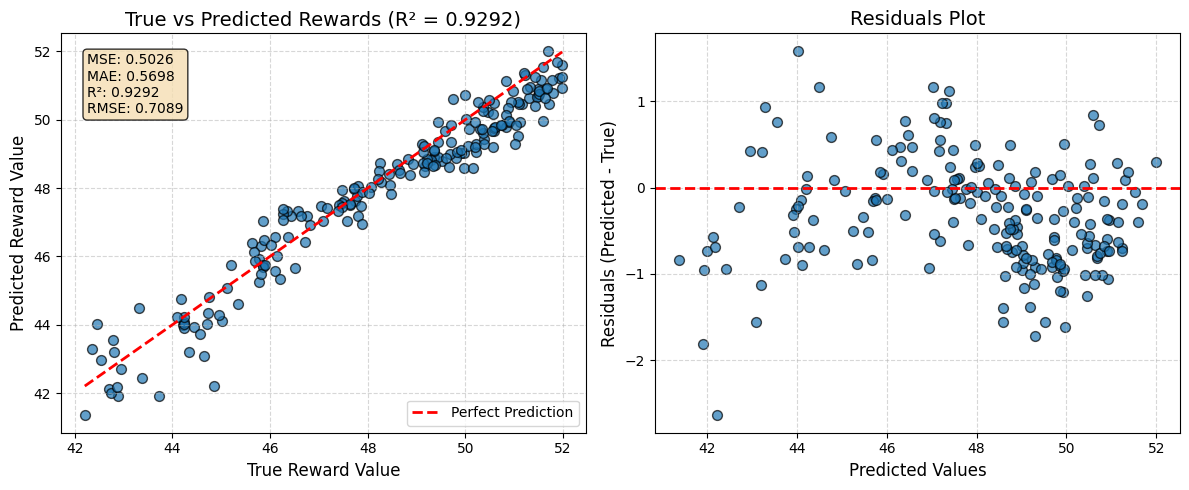

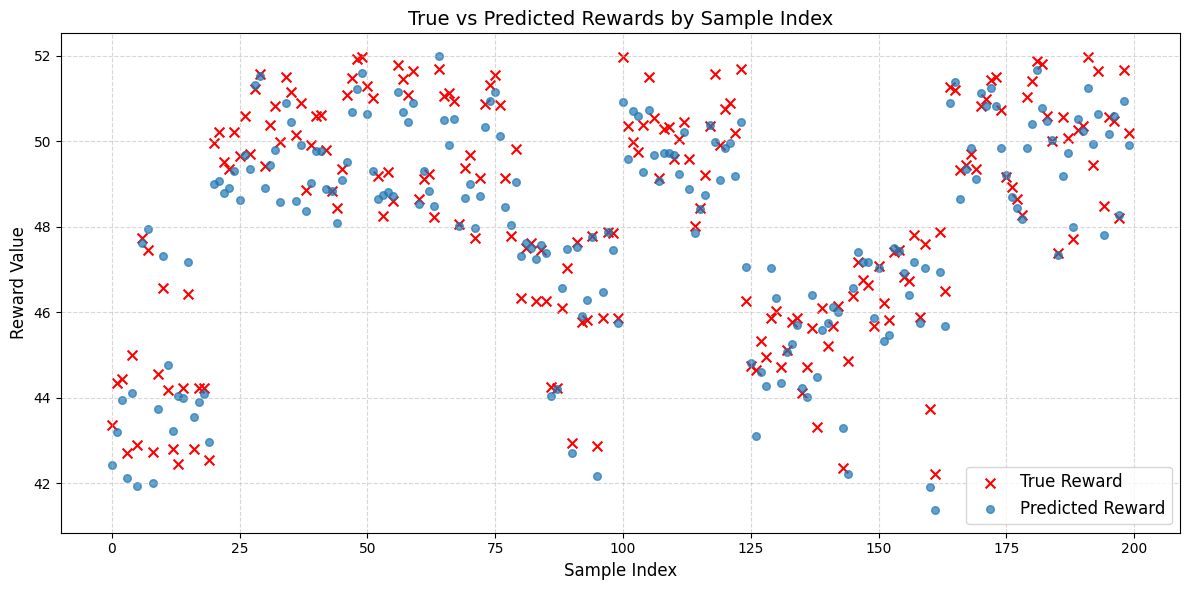


Simple prediction completed! Generated 200 predictions.

Simple Metrics Summary:
  R² Score: 0.9292
  RMSE: 0.7089
  MAE: 0.5698

RUNNING ENHANCED EVALUATION (Predictions vs True Values vs GT Classes)
Loading regressor model from: models/fixed_regressor_20250722_205631/best_model.pth
Secure loading failed, trying with weights_only=False: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy.core.multiarray.scalar was 

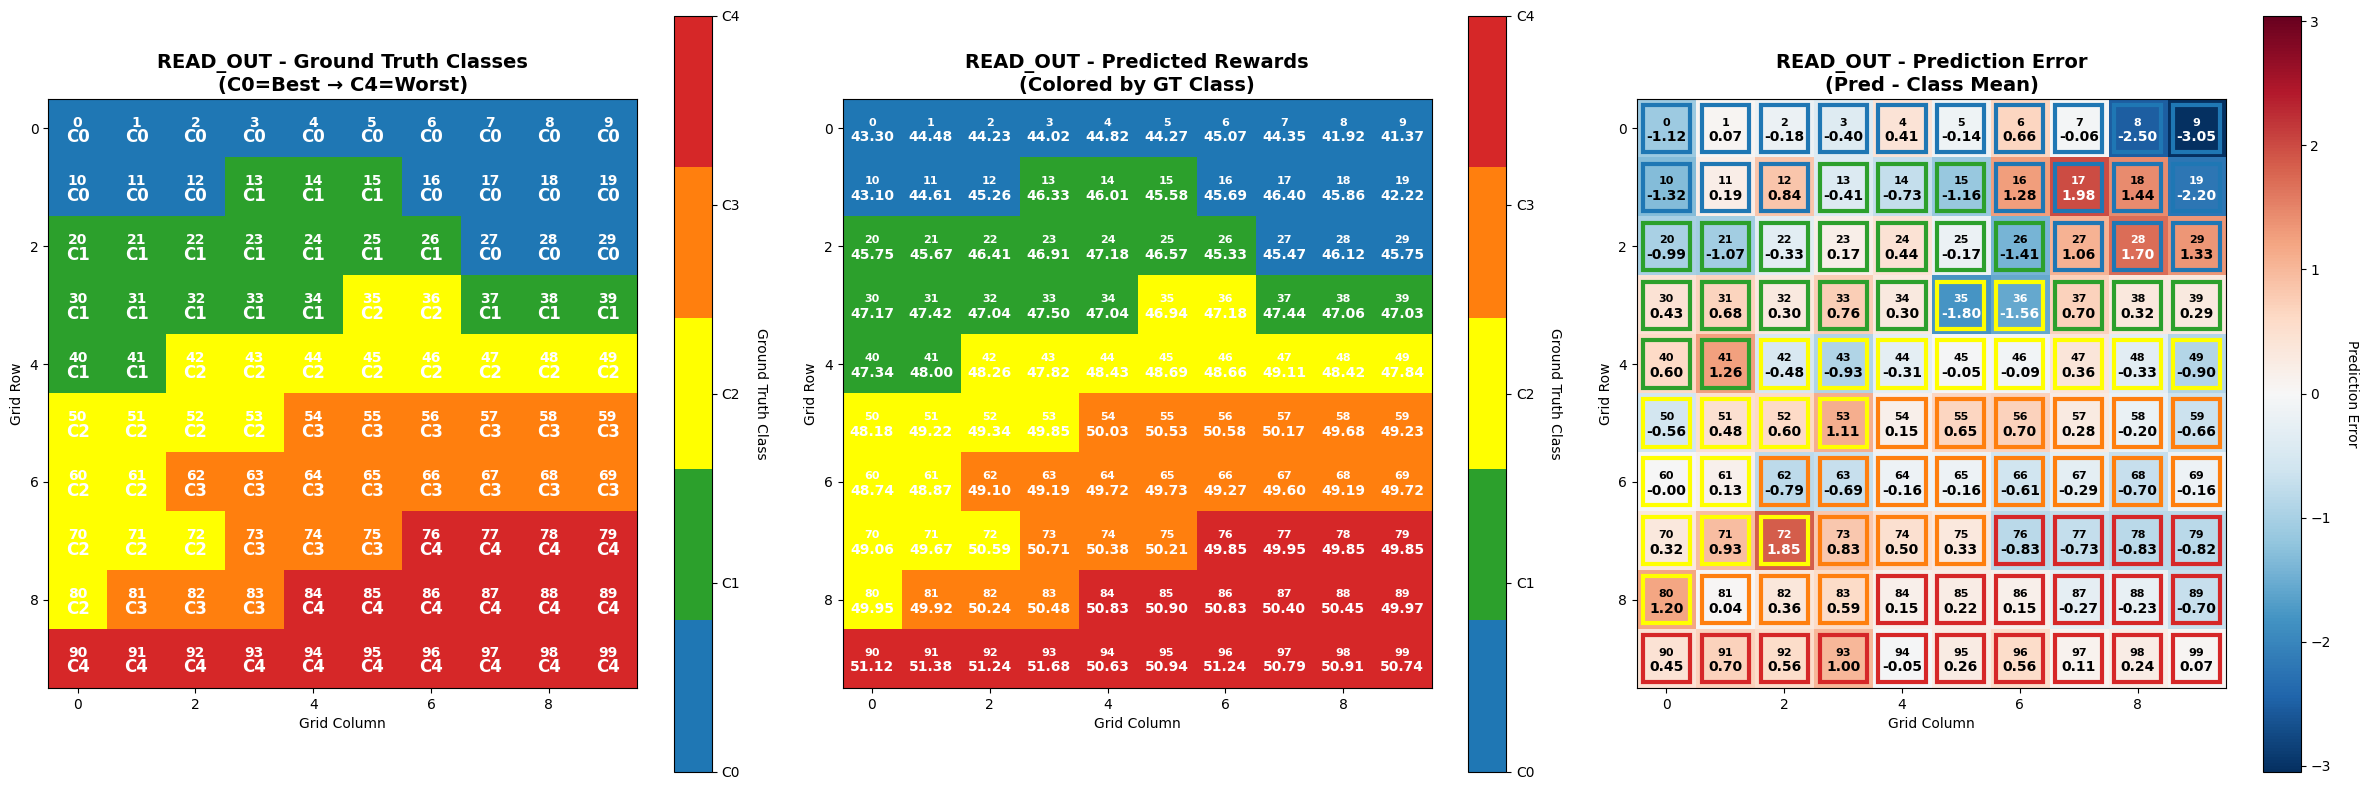


read_out Statistics:
  Predictions: 100 valid values
  Prediction range: [41.370, 51.679]
  Prediction mean: 48.092 ± 2.427
  Ground-truth classes: 100 valid labels
  Class distribution: {0: 20, 1: 20, 2: 20, 3: 20, 4: 20}
  Prediction statistics by class:
    Class 0: 20 samples, mean=44.416 ± 1.385
    Class 1: 20 samples, mean=46.738 ± 0.726
    Class 2: 20 samples, mean=48.742 ± 0.892
    Class 3: 20 samples, mean=49.885 ± 0.506
    Class 4: 20 samples, mean=50.677 ± 0.537

=== WEAR_OUT DATASET - PREDICTIONS vs GROUND TRUTH ===
Converted grid from list to numpy array with shape: (10, 10)


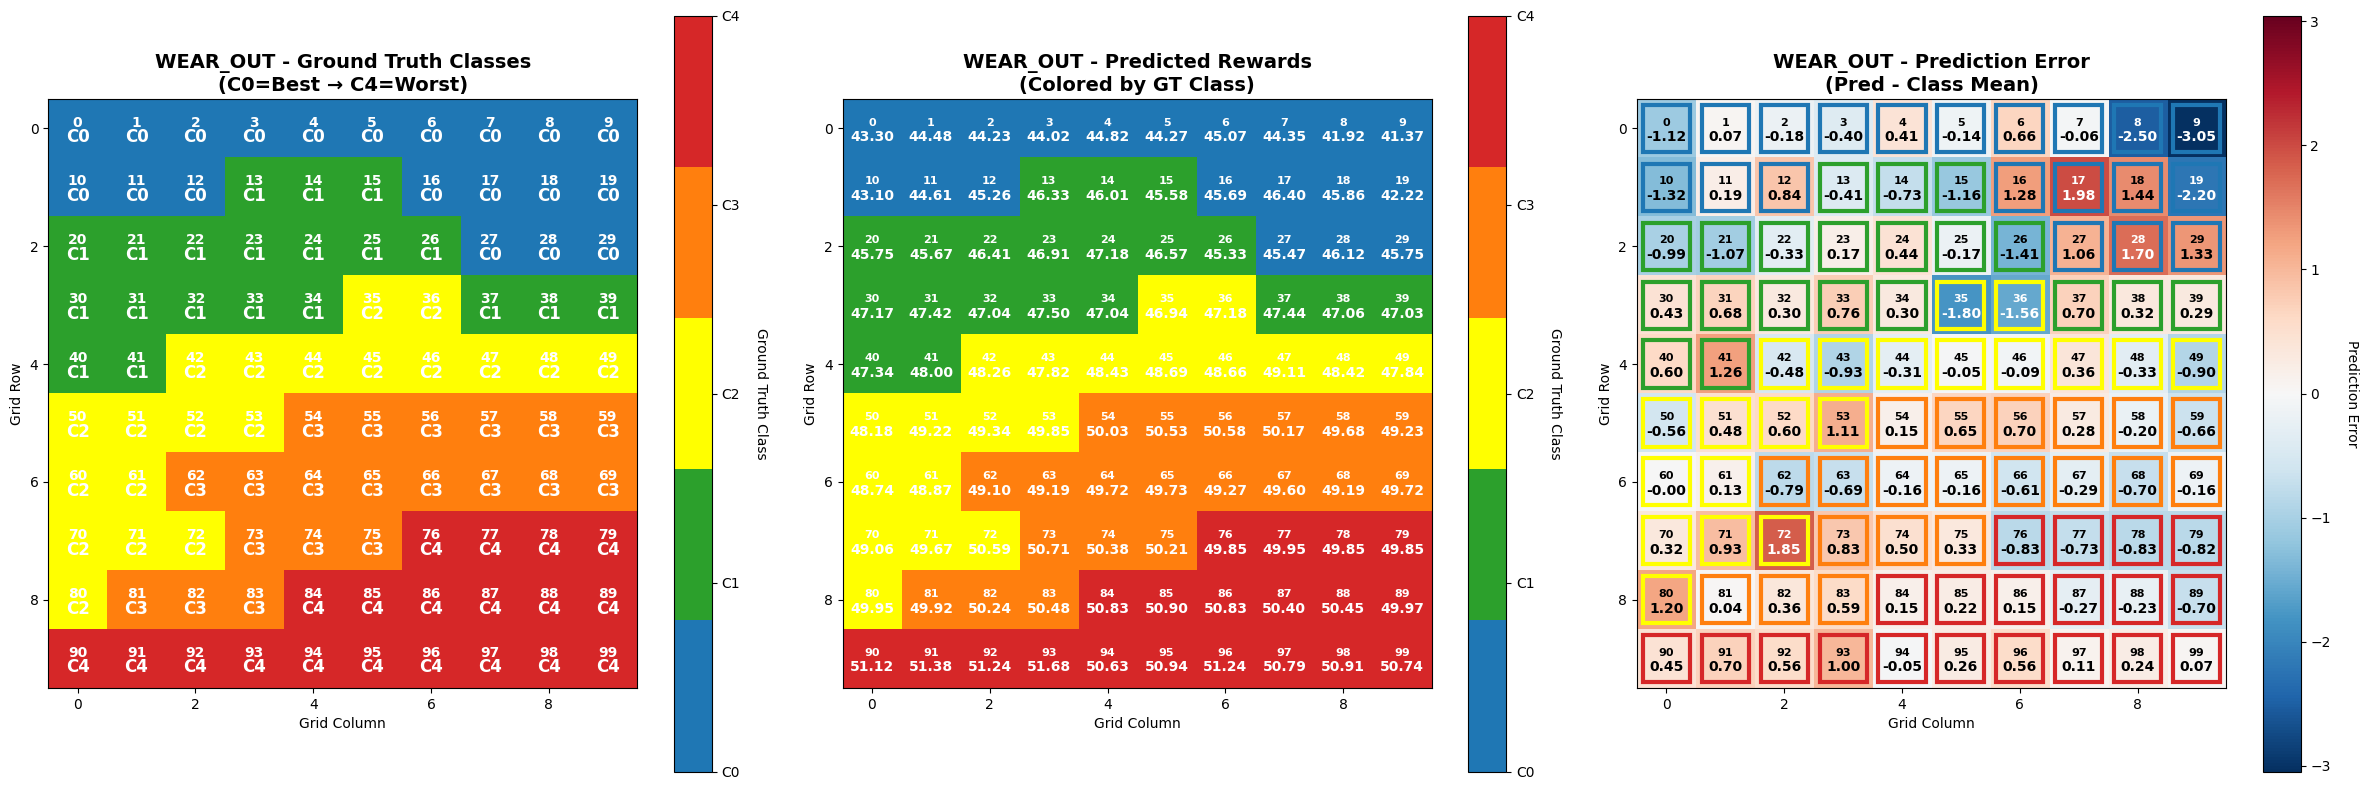


wear_out Statistics:
  Predictions: 100 valid values
  Prediction range: [41.370, 51.679]
  Prediction mean: 48.092 ± 2.427
  Ground-truth classes: 100 valid labels
  Class distribution: {0: 20, 1: 20, 2: 20, 3: 20, 4: 20}
  Prediction statistics by class:
    Class 0: 20 samples, mean=44.416 ± 1.385
    Class 1: 20 samples, mean=46.738 ± 0.726
    Class 2: 20 samples, mean=48.742 ± 0.892
    Class 3: 20 samples, mean=49.885 ± 0.506
    Class 4: 20 samples, mean=50.677 ± 0.537

EVALUATION METRICS WITH CLASS ANALYSIS
  Overall Performance:
    R² Score: 0.9292
    RMSE: 0.7089
    MAE: 0.5698

  Performance by Ground-Truth Class:
    Class 0: 40 samples, RMSE=0.8500, MAE=0.6696
      True range: [42.204, 45.853], Pred range: [41.370, 46.401]
    Class 1: 40 samples, RMSE=0.5185, MAE=0.4017
      True range: [45.770, 47.794], Pred range: [45.330, 48.048]
    Class 2: 40 samples, RMSE=0.4290, MAE=0.3464
      True range: [47.808, 49.751], Pred range: [46.939, 50.591]
    Class 3: 40 samp

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import r2_score, mean_squared_error
from torch.utils.data import DataLoader
from tools import (
    get_all_ibw_files, get_ibw_grid, compute_and_display_class_grid,
    extract_scan_index_from_filename, load_ibw, compute_rewards_for_files,
    generate_labels_from_rewards_stratified_separated
)

# Import the updated model and dataset classes

def load_trained_regressor_model(model_path, device=None, config_path=None):
    """
    Load trained regressor model with proper configuration and handle PyTorch 2.6+ loading
    """
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 
                            'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 
                            'cpu')
    
    # Load model configuration if available
    model_config = None
    if config_path and os.path.exists(config_path):
        with open(config_path, 'r') as f:
            model_config = json.load(f)
    
    # Create model with configuration
    if model_config:
        model = StratifiedRegressor(
            hidden_sizes=model_config.get('hidden_sizes', [512, 256, 128]),
            num_classes=model_config.get('num_classes', None),
            dropout_rate=model_config.get('dropout_rate', 0.2),
            use_batch_norm=model_config.get('use_batch_norm', True),
            activation=model_config.get('activation', 'relu')
        )
    else:
        # Default configuration
        model = StratifiedRegressor(
            hidden_sizes=[512, 256, 128],
            num_classes=None,
            dropout_rate=0.2,
            use_batch_norm=True,
            activation='relu'
        )
    
    model.to(device)
    
    # Load model weights with proper handling for PyTorch 2.6+
    if model_path.endswith('_full.pth'):
        # Loading full model - need to use weights_only=False for full models
        try:
            model = torch.load(model_path, map_location=device, weights_only=False)
        except Exception as e:
            print(f"Error loading full model: {e}")
            # Fallback: try with safe globals
            torch.serialization.add_safe_globals([np.core.multiarray.scalar])
            model = torch.load(model_path, map_location=device, weights_only=False)
    else:
        # Loading state dict - try weights_only=True first, fallback if needed
        try:
            # First try with weights_only=True (secure)
            checkpoint = torch.load(model_path, map_location=device, weights_only=True)
        except Exception as e:
            print(f"Secure loading failed, trying with weights_only=False: {e}")
            try:
                # Fallback to weights_only=False (less secure but should work)
                checkpoint = torch.load(model_path, map_location=device, weights_only=False)
            except Exception as e2:
                print(f"Standard loading also failed, trying with safe globals: {e2}")
                # Add numpy globals to safe list and try again
                torch.serialization.add_safe_globals([np.core.multiarray.scalar])
                checkpoint = torch.load(model_path, map_location=device, weights_only=True)
        
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            # Handle the case where model_state_dict contains extra keys like target_mean, target_std
            model_state_dict = checkpoint['model_state_dict'].copy()
            
            # Extract target scaling parameters if they exist
            target_mean = model_state_dict.pop('target_mean', None)
            target_std = model_state_dict.pop('target_std', None)
            
            # Load the model state dict WITHOUT the scaling parameters
            model.load_state_dict(model_state_dict)
            
            # AFTER loading, register scaling parameters as buffers if they exist
            if target_mean is not None and target_std is not None:
                model.register_buffer('target_mean', target_mean)
                model.register_buffer('target_std', target_std)
                print(f"  Found target scaling: mean={target_mean.item():.4f}, std={target_std.item():.4f}")
            
            epoch_info = checkpoint.get('epoch', 'Unknown')
        else:
            # Handle direct state dict with potential extra keys
            state_dict = checkpoint.copy() if isinstance(checkpoint, dict) else checkpoint
            
            # Extract target scaling parameters if they exist
            target_mean = state_dict.pop('target_mean', None)
            target_std = state_dict.pop('target_std', None)
            
            # Load the model state dict WITHOUT the scaling parameters
            model.load_state_dict(state_dict)
            
            # AFTER loading, register scaling parameters as buffers if they exist
            if target_mean is not None and target_std is not None:
                model.register_buffer('target_mean', target_mean)
                model.register_buffer('target_std', target_std)
                print(f"  Found target scaling: mean={target_mean.item():.4f}, std={target_std.item():.4f}")
            
            epoch_info = 'Unknown'
        
        print(f"Model loaded from {model_path}, trained for {epoch_info} epochs")
    
    model.eval()
    return model

def regressor_predict_batch(model, ibw_files, device, batch_size=32):
    """
    Predict rewards for a batch of IBW files using the trained regressor
    """
    model.eval()
    predictions = []
    
    # Create dataset and dataloader
    dataset = FixedAugmentedIBWDataset(
        ibw_files=ibw_files,
        labels=[0.0] * len(ibw_files),  # Dummy labels
        scan_indices=list(range(len(ibw_files))),
        compute_rewards=False,
        use_augmentation=False
    )
    
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=regression_collate_fn,
        num_workers=0
    )
    
    with torch.no_grad():
        for batch_idx, (inputs, _) in enumerate(dataloader):
            inputs = inputs.to(device)
            
            # Forward pass
            outputs = model(inputs)
            reward_predictions = outputs['reward'].squeeze()
            
            # Apply inverse target scaling if model has scaling parameters
            if hasattr(model, 'target_mean') and hasattr(model, 'target_std'):
                reward_predictions = reward_predictions * model.target_std + model.target_mean
            
            # Handle single sample case
            if reward_predictions.dim() == 0:
                reward_predictions = reward_predictions.unsqueeze(0)
            
            # Convert to numpy and store
            batch_predictions = reward_predictions.cpu().numpy()
            
            # Add predictions with filenames
            start_idx = batch_idx * batch_size
            for i, pred_value in enumerate(batch_predictions):
                file_idx = start_idx + i
                if file_idx < len(ibw_files):
                    filename = os.path.basename(ibw_files[file_idx])
                    scan_index = extract_scan_index_from_filename(filename)
                    
                    predictions.append({
                        'filename': filename,
                        'scan_index': scan_index,
                        'predicted_value': float(pred_value)
                    })
    
    return predictions


def regressor_predict_single(model, ibw_files, device):
    """
    Predict rewards for IBW files one by one (alternative approach)
    """
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for file_path in ibw_files:
            try:
                # Load and process single file
                ibw_data = load_ibw(file_path)
                ch_names = ibw_data.channels
                
                # Extract the 6 channels as numpy arrays
                amp_trace = ibw_data.data[ch_names.index('Amplitude (T)')]
                amp_retrace = ibw_data.data[ch_names.index('Amplitude (RT)')]
                phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
                phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
                height_trace = ibw_data.data[ch_names.index('Height (T)')]
                height_retrace = ibw_data.data[ch_names.index('Height (RT)')]
                
                # Stack channels: shape (6, H, W)
                input_np = np.stack([
                    amp_trace, amp_retrace,
                    phase_trace, phase_retrace,
                    height_trace, height_retrace
                ], axis=0).astype(np.float32)
                
                # Robust normalization (same as in training)
                for i in range(input_np.shape[0]):
                    channel = input_np[i]
                    mean_val = np.mean(channel)
                    std_val = np.std(channel)
                    if std_val > 1e-8:
                        channel = np.clip(channel, mean_val - 3*std_val, mean_val + 3*std_val)
                        input_np[i] = (channel - mean_val) / (std_val + 1e-8)
                    else:
                        input_np[i] = channel - mean_val
                
                # Convert to tensor and add batch dimension
                input_tensor = torch.tensor(input_np, dtype=torch.float32).unsqueeze(0).to(device)
                
                # Forward pass
                outputs = model(input_tensor)
                predicted_reward = outputs['reward'].squeeze()
                
                # Apply inverse target scaling if model has scaling parameters
                if hasattr(model, 'target_mean') and hasattr(model, 'target_std'):
                    predicted_reward = predicted_reward * model.target_std + model.target_mean
                
                predicted_reward = predicted_reward.item()
                
                # Extract scan index
                filename = os.path.basename(file_path)
                scan_index = extract_scan_index_from_filename(filename)
                
                predictions.append({
                    'filename': filename,
                    'scan_index': scan_index,
                    'predicted_value': predicted_reward
                })
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
                filename = os.path.basename(file_path)
                scan_index = extract_scan_index_from_filename(filename)
                predictions.append({
                    'filename': filename,
                    'scan_index': scan_index,
                    'predicted_value': 0.0
                })
    
    return predictions


def evaluate_regressor_with_true_rewards(model, base_folder, dataset_names, reward_weights, batch_size=32, use_batch_prediction=True, apply_target_scaling=True):
    """
    Evaluate the regressor on specified datasets with true rewards computed from reward weights
    (Adapted from the classification model's evaluation approach)
    """
    device = next(model.parameters()).device
    all_results = []
    predicted_values_dict = {}
    
    for dataset_name in dataset_names:
        dataset_path = os.path.join(base_folder, dataset_name)
        ibw_files = get_all_ibw_files(dataset_path)
        print(f"\nLoaded {len(ibw_files)} files from {dataset_name}")
        
        # Compute true rewards using the same approach as classification model
        print(f"Computing true rewards for {dataset_name}...")
        rewards, _ = compute_rewards_for_files(ibw_files, reward_weights)
        
        # CRITICAL FIX: Apply target scaling if needed
        if apply_target_scaling:
            rewards_array = np.array(rewards)
            original_mean, original_std = rewards_array.mean(), rewards_array.std()
            print(f"  Original reward stats: mean={original_mean:.4f}, std={original_std:.4f}")
            
            # Check if model has target scaling parameters
            if hasattr(model, 'target_mean') and hasattr(model, 'target_std'):
                model_mean = model.target_mean.item()
                model_std = model.target_std.item()
                print(f"  Model was trained with target scaling: mean={model_mean:.4f}, std={model_std:.4f}")
                print(f"  Predictions will be automatically rescaled to original scale")
            else:
                print(f"  No target scaling found in model - using raw predictions")
        
        # Choose prediction method
        if use_batch_prediction and len(ibw_files) > 10:
            preds = regressor_predict_batch(model, ibw_files, device, batch_size)
        else:
            preds = regressor_predict_single(model, ibw_files, device)
        
        # Process predictions and match with true rewards
        for i, pred in enumerate(preds):
            scan_index = pred['scan_index']
            predicted_values_dict[scan_index] = pred['predicted_value']
            
            # Add true reward value (matching by index in the original files list)
            if i < len(rewards):
                pred['true_value'] = rewards[i]
            else:
                print(f"Warning: No true reward found for prediction {i}")
                pred['true_value'] = None
            
            all_results.append(pred)
    
    # Calculate metrics with true values
    valid_results = [p for p in all_results if p.get('true_value') is not None]
    
    if valid_results:
        y_true = np.array([p['true_value'] for p in valid_results])
        y_pred = np.array([p['predicted_value'] for p in valid_results])
        
        mse = mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mae = np.mean(np.abs(y_true - y_pred))
        
        print(f"\n{'='*50}")
        print(f"REGRESSOR EVALUATION RESULTS")
        print(f"{'='*50}")
        print(f"  Number of valid samples: {len(valid_results)}")
        
        # DIAGNOSTIC INFO
        print(f"\n  DIAGNOSTIC INFORMATION:")
        print(f"  True values  - Min: {y_true.min():.4f}, Max: {y_true.max():.4f}, Mean: {y_true.mean():.4f}, Std: {y_true.std():.4f}")
        print(f"  Pred values  - Min: {y_pred.min():.4f}, Max: {y_pred.max():.4f}, Mean: {y_pred.mean():.4f}, Std: {y_pred.std():.4f}")
        
        pred_unique = len(np.unique(np.round(y_pred, 4)))
        print(f"  Unique predictions: {pred_unique}")
        if pred_unique < 10:
            print(f"  ⚠️  WARNING: Very few unique predictions - model may be stuck!")
            
        scale_ratio = (y_pred.max() - y_pred.min()) / (y_true.max() - y_true.min())
        print(f"  Scale ratio (pred_range/true_range): {scale_ratio:.4f}")
        if scale_ratio < 0.1:
            print(f"  ⚠️  CRITICAL: Prediction scale much smaller than true scale!")
            print(f"  ⚠️  This suggests: 1) Output activation constraint, 2) Poor learning, or 3) Scaling mismatch")
        
        print(f"\n  PERFORMANCE METRICS:")
        print(f"  Mean Squared Error (MSE): {mse:.4f}")
        print(f"  Root Mean Squared Error (RMSE): {np.sqrt(mse):.4f}")
        print(f"  Mean Absolute Error (MAE): {mae:.4f}")
        print(f"  R² Score: {r2:.4f}")
        print(f"  True values range: [{y_true.min():.4f}, {y_true.max():.4f}]")
        print(f"  Predicted values range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
        
        # Plot results - True vs Predicted scatter plot
        plt.figure(figsize=(12, 5))
        
        # Subplot 1: Scatter plot
        plt.subplot(1, 2, 1)
        plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k', s=50)
        plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', linewidth=2, label='Perfect Prediction')
        plt.xlabel('True Reward Value', fontsize=12)
        plt.ylabel('Predicted Reward Value', fontsize=12)
        plt.title(f'True vs Predicted Rewards (R² = {r2:.4f})', fontsize=14)
        plt.legend(fontsize=10)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        # Add statistics text box
        stats_text = f'MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\nRMSE: {np.sqrt(mse):.4f}'
        plt.text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Subplot 2: Residuals plot
        plt.subplot(1, 2, 2)
        residuals = y_pred - y_true
        plt.scatter(y_pred, residuals, alpha=0.7, edgecolor='k', s=50)
        plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
        plt.xlabel('Predicted Values', fontsize=12)
        plt.ylabel('Residuals (Predicted - True)', fontsize=12)
        plt.title('Residuals Plot', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.5)
        
        plt.tight_layout()
        plt.show()
        
        # Additional plot: Prediction vs Sample Index (similar to classification approach)
        plt.figure(figsize=(12, 6))
        sample_indices = range(len(valid_results))
        plt.scatter(sample_indices, y_true, label='True Reward', marker='x', color='red', s=50)
        plt.scatter(sample_indices, y_pred, label='Predicted Reward', marker='o', alpha=0.7, s=30)
        plt.xlabel('Sample Index', fontsize=12)
        plt.ylabel('Reward Value', fontsize=12)
        plt.title('True vs Predicted Rewards by Sample Index', fontsize=14)
        plt.legend(fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()
        
        return all_results, predicted_values_dict, {'mse': mse, 'r2': r2, 'mae': mae, 'rmse': np.sqrt(mse)}
    else:
        print("No valid samples found for evaluation!")
        return all_results, predicted_values_dict, None


def plot_prediction_grid_regressor(predicted_values_dict, base_folder, dataset_names, grid_size=10):
    """
    Plot prediction grids for each dataset using the same approach as classification model
    """
    for dataset_name in dataset_names:
        print(f"\n=== {dataset_name.upper()} DATASET - PREDICTED REWARD VALUES GRID ===")
        
        # Get grid using same approach as classification model
        grid = get_ibw_grid(f'{base_folder}/{dataset_name}', grid_size=grid_size)
        
        # Use the same grid display function
        predicted_reward_grid, _ = compute_and_display_class_grid(
            grid, 
            predicted_values_dict,
        )


def load_model_and_predict_with_true_rewards(model_dir, base_folder, dataset_names, reward_weights):
    """
    Complete workflow: load model and make predictions with true reward comparison
    (Adapted from classification model evaluation approach)
    """
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 
                        'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 
                        'cpu')
    
    # Load model
    model_path = os.path.join(model_dir, "best_model.pth")
    config_path = os.path.join(model_dir, "best_model_config.json")
    
    if not os.path.exists(model_path):
        # Try full model
        model_path = os.path.join(model_dir, "best_model_full.pth")
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"No model found in {model_dir}")
    
    print(f"Loading regressor model from: {model_path}")
    model = load_trained_regressor_model(model_path, device, config_path)
    
    # Make predictions with true rewards
    results, predicted_values_dict, metrics = evaluate_regressor_with_true_rewards(
        model, base_folder, dataset_names, reward_weights
    )
    
    # Plot grids (same as classification model approach)
    plot_prediction_grid_regressor(predicted_values_dict, base_folder, dataset_names)
    
    return results, predicted_values_dict, metrics

def compute_and_display_regression_grid(grid, predicted_values_dict, dataset_name="Dataset", cmap='viridis'):
    """
    Create and display a grid for regression predictions (continuous values)
    Adapted from compute_and_display_class_grid for regression use
    FIXED: Handle case where grid is a list instead of numpy array
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Convert grid to numpy array if it's a list
    if isinstance(grid, list):
        grid = np.array(grid)
    
    grid_size = grid.shape[0]
    prediction_grid = np.full((grid_size, grid_size), np.nan)
    
    # Fill grid with predictions
    for i in range(grid_size):
        for j in range(grid_size):
            scan_index = grid[i, j]
            if scan_index in predicted_values_dict:
                prediction_grid[i, j] = predicted_values_dict[scan_index]
    
    # Create the plot
    plt.figure(figsize=(10, 8))
    
    # Use imshow for continuous values with colormap
    im = plt.imshow(prediction_grid, cmap=cmap, interpolation='nearest')
    plt.colorbar(im, label='Predicted Reward Value')
    
    # Add grid lines
    plt.grid(True, which='major', alpha=0.3)
    
    # Set ticks and labels
    plt.xticks(range(grid_size), range(grid_size))
    plt.yticks(range(grid_size), range(grid_size))
    
    # Add text annotations with predicted values
    for i in range(grid_size):
        for j in range(grid_size):
            scan_index = grid[i, j]
            if scan_index in predicted_values_dict:
                pred_val = predicted_values_dict[scan_index]
                # Use white text on dark colors, black on light colors
                text_color = 'white' if pred_val < np.nanmean(prediction_grid) else 'black'
                plt.text(j, i, f'{scan_index}\n{pred_val:.3f}', 
                        ha='center', va='center', fontsize=8, color=text_color, weight='bold')
            else:
                plt.text(j, i, f'{scan_index}\nN/A', 
                        ha='center', va='center', fontsize=8, color='red')
    
    plt.title(f'{dataset_name} - Predicted Reward Values Grid', fontsize=14, pad=20)
    plt.xlabel('Column Index', fontsize=12)
    plt.ylabel('Row Index', fontsize=12)
    
    # Add statistics
    valid_predictions = prediction_grid[~np.isnan(prediction_grid)]
    if len(valid_predictions) > 0:
        stats_text = f'Min: {valid_predictions.min():.3f}\nMax: {valid_predictions.max():.3f}\nMean: {valid_predictions.mean():.3f}\nStd: {valid_predictions.std():.3f}'
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    return prediction_grid


def plot_prediction_grid_regressor_fixed(predicted_values_dict, base_folder, dataset_names, grid_size=10):
    """
    Fixed version of plot_prediction_grid_regressor that works with continuous regression values
    FIXED: Handle case where get_ibw_grid returns a list
    """
    from tools import get_ibw_grid
    import numpy as np
    
    for dataset_name in dataset_names:
        print(f"\n=== {dataset_name.upper()} DATASET - PREDICTED REWARD VALUES GRID ===")
        
        # Get grid using same approach as classification model
        grid = get_ibw_grid(f'{base_folder}/{dataset_name}', grid_size=grid_size)
        
        # Convert to numpy array if needed
        if isinstance(grid, list):
            grid = np.array(grid)
            print(f"Converted grid from list to numpy array with shape: {grid.shape}")
        
        # Use the fixed regression-specific grid display function
        predicted_reward_grid = compute_and_display_regression_grid(
            grid, 
            predicted_values_dict,
            dataset_name=dataset_name.upper()
        )

""""""""""""
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

def compute_and_display_regression_grid_with_gt_classes(grid, predicted_values_dict, ground_truth_labels_dict, 
                                                       dataset_name="Dataset", scan_start=0):
    """
    Display a grid showing both regression predictions and ground-truth stratified class labels.
    
    Args:
        grid: 2D array of ibw objects from get_ibw_grid()
        predicted_values_dict: Dictionary mapping scan_index to predicted reward values
        ground_truth_labels_dict: Dictionary mapping scan_index to ground-truth stratified class labels
        dataset_name: Name of the dataset for display
        scan_start: Starting scan index (default 0)
    
    Returns:
        prediction_grid: 2D numpy array of predicted reward values
        gt_class_grid: 2D numpy array of ground-truth class assignments
    """
    n_rows = len(grid)
    n_cols = len(grid[0]) if n_rows > 0 else 0
    
    # Initialize grids
    prediction_grid = np.full((n_rows, n_cols), np.nan)
    gt_class_grid = np.full((n_rows, n_cols), -1, dtype=int)  # -1 for missing data
    
    # Fill grids
    for i in range(n_rows):
        for j in range(n_cols):
            ibw_obj = grid[i][j]
            if ibw_obj is not None:
                scan_index = i * n_cols + j + scan_start
                
                # Get predicted reward
                if scan_index in predicted_values_dict:
                    prediction_grid[i, j] = predicted_values_dict[scan_index]
                
                # Get ground-truth class label
                if scan_index in ground_truth_labels_dict:
                    gt_class_grid[i, j] = ground_truth_labels_dict[scan_index]
    
    # Create the visualization
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
    
    # Define colors for each class (0=best to 4=worst)
    class_colors = ['#1f77b4',  '#2ca02c', '#ffff00', '#ff7f0e', '#d62728']  # Added 6th color
    class_cmap = ListedColormap(class_colors)
    
    # Plot 1: Ground-truth class assignments
    masked_class_grid = np.ma.masked_where(gt_class_grid == -1, gt_class_grid)
    num_classes = len(class_colors)
    im1 = ax1.imshow(masked_class_grid, cmap=class_cmap, vmin=0, vmax=num_classes - 1)
    
    # Add text annotations and colored boxes for classes
    for i in range(n_rows):
        for j in range(n_cols):
            scan_index = i * n_cols + j + scan_start
            if gt_class_grid[i, j] != -1:
                # Add colored box border
                rect = Rectangle((j-0.4, i-0.4), 0.8, 0.8, 
                               linewidth=3, edgecolor=class_colors[gt_class_grid[i, j]], 
                               facecolor='none')
                ax1.add_patch(rect)
                
                # Add scan index and class label text
                ax1.text(j, i-0.1, f"{scan_index}", ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=10)
                ax1.text(j, i+0.15, f"C{gt_class_grid[i, j]}", ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=12)
            else:
                ax1.text(j, i, f"{scan_index}\nN/A", ha='center', va='center', 
                        color='gray', fontsize=10)
    
    ax1.set_title(f"{dataset_name} - Ground Truth Classes\n(C0=Best → C{num_classes-1}=Worst)", 
                  fontsize=14, fontweight='bold')
    ax1.set_xlabel("Grid Column")
    ax1.set_ylabel("Grid Row")
    
    # Create custom colorbar for classes
    cbar1 = plt.colorbar(im1, ax=ax1, ticks=list(range(num_classes)))
    cbar1.set_label('Ground Truth Class', rotation=270, labelpad=20)
    cbar1.set_ticklabels([f'C{i}' for i in range(num_classes)])
    
    # Plot 2: Predicted reward values (colored by ground truth class, no borders)
    # Use the same class color background as Plot 1
    masked_class_grid_plot2 = np.ma.masked_where(gt_class_grid == -1, gt_class_grid)
    im2 = ax2.imshow(masked_class_grid_plot2, cmap=class_cmap, vmin=0, vmax=num_classes - 1)
    
    # Add predicted values as text (NO border rectangles)
    for i in range(n_rows):
        for j in range(n_cols):
            scan_index = i * n_cols + j + scan_start
            if not np.isnan(prediction_grid[i, j]):
                # Add scan index and predicted value text (no colored borders)
                ax2.text(j, i-0.1, f"{scan_index}", ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=8)
                ax2.text(j, i+0.15, f"{prediction_grid[i, j]:.2f}", ha='center', va='center', 
                        color='white', fontweight='bold', fontsize=10)
            else:
                ax2.text(j, i, f"{scan_index}\nN/A", ha='center', va='center', 
                        color='gray', fontsize=10)
    
    ax2.set_title(f"{dataset_name} - Predicted Rewards\n(Colored by GT Class)", 
                  fontsize=14, fontweight='bold')
    ax2.set_xlabel("Grid Column")
    ax2.set_ylabel("Grid Row")
    
    cbar2 = plt.colorbar(im2, ax=ax2, ticks=list(range(num_classes)))
    cbar2.set_label('Ground Truth Class', rotation=270, labelpad=20)
    cbar2.set_ticklabels([f'C{i}' for i in range(num_classes)])
    
    # Plot 3: Difference/Error analysis (Predicted vs Expected based on class)
    # Calculate class-based expected values
    class_expected_values = {}
    valid_predictions = prediction_grid[~np.isnan(prediction_grid)]
    valid_classes = gt_class_grid[gt_class_grid != -1]
    
    if len(valid_predictions) > 0 and len(valid_classes) > 0:
        for class_id in range(num_classes):
            class_mask = (gt_class_grid == class_id) & (~np.isnan(prediction_grid))
            if np.any(class_mask):
                class_expected_values[class_id] = np.mean(prediction_grid[class_mask])
        
        # Create error grid (prediction - class mean)
        error_grid = np.full((n_rows, n_cols), np.nan)
        for i in range(n_rows):
            for j in range(n_cols):
                if not np.isnan(prediction_grid[i, j]) and gt_class_grid[i, j] != -1:
                    expected_val = class_expected_values.get(gt_class_grid[i, j], prediction_grid[i, j])
                    error_grid[i, j] = prediction_grid[i, j] - expected_val
        
        # Plot error grid
        max_abs_error = np.nanmax(np.abs(error_grid)) if not np.isnan(error_grid).all() else 1
        im3 = ax3.imshow(error_grid, cmap='RdBu_r', vmin=-max_abs_error, vmax=max_abs_error)
        
        # Add error values with class-colored borders
        for i in range(n_rows):
            for j in range(n_cols):
                scan_index = i * n_cols + j + scan_start
                if not np.isnan(error_grid[i, j]):
                    # Add colored box border based on ground-truth class
                    if gt_class_grid[i, j] != -1:
                        rect = Rectangle((j-0.4, i-0.4), 0.8, 0.8, 
                                       linewidth=3, edgecolor=class_colors[gt_class_grid[i, j]], 
                                       facecolor='none')
                        ax3.add_patch(rect)
                    
                    # Add scan index and error value text
                    text_color = 'white' if abs(error_grid[i, j]) > max_abs_error/2 else 'black'
                    ax3.text(j, i-0.1, f"{scan_index}", ha='center', va='center', 
                            color=text_color, fontweight='bold', fontsize=8)
                    ax3.text(j, i+0.15, f"{error_grid[i, j]:.2f}", ha='center', va='center', 
                            color=text_color, fontweight='bold', fontsize=10)
                else:
                    ax3.text(j, i, f"{scan_index}\nN/A", ha='center', va='center', 
                            color='gray', fontsize=10)
        
        ax3.set_title(f"{dataset_name} - Prediction Error\n(Pred - Class Mean)", 
                      fontsize=14, fontweight='bold')
        ax3.set_xlabel("Grid Column")
        ax3.set_ylabel("Grid Row")
        
        cbar3 = plt.colorbar(im3, ax=ax3)
        cbar3.set_label('Prediction Error', rotation=270, labelpad=20)
    else:
        ax3.text(0.5, 0.5, 'Insufficient data\nfor error analysis', 
                ha='center', va='center', transform=ax3.transAxes, fontsize=16)
        ax3.set_title(f"{dataset_name} - Error Analysis\n(Not Available)", 
                      fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return prediction_grid, gt_class_grid

def plot_prediction_grid_regressor_with_gt(predicted_values_dict, ground_truth_labels_dict, 
                                          base_folder, dataset_names, grid_size=10):
    """
    Plot prediction grids for each dataset showing both regression predictions 
    and ground-truth stratified class labels.
    
    Args:
        predicted_values_dict: Dictionary mapping scan_index to predicted reward values
        ground_truth_labels_dict: Dictionary mapping scan_index to ground-truth class labels
        base_folder: Base folder path
        dataset_names: List of dataset names
        grid_size: Size of the grid (default 10x10)
    """
    from tools import get_ibw_grid
    
    for dataset_name in dataset_names:
        print(f"\n=== {dataset_name.upper()} DATASET - PREDICTIONS vs GROUND TRUTH ===")
        
        # Get grid using same approach as classification model
        grid = get_ibw_grid(f'{base_folder}/{dataset_name}', grid_size=grid_size)
        
        # Convert to numpy array if needed
        if isinstance(grid, list):
            grid = np.array(grid)
            print(f"Converted grid from list to numpy array with shape: {grid.shape}")
        
        # Use the enhanced grid display function
        predicted_reward_grid, gt_class_grid = compute_and_display_regression_grid_with_gt_classes(
            grid, 
            predicted_values_dict,
            ground_truth_labels_dict,
            dataset_name=dataset_name.upper()
        )
        
        # Print statistics for this dataset
        valid_predictions = predicted_reward_grid[~np.isnan(predicted_reward_grid)]
        valid_classes = gt_class_grid[gt_class_grid != -1]
        
        if len(valid_predictions) > 0:
            print(f"\n{dataset_name} Statistics:")
            print(f"  Predictions: {len(valid_predictions)} valid values")
            print(f"  Prediction range: [{valid_predictions.min():.3f}, {valid_predictions.max():.3f}]")
            print(f"  Prediction mean: {valid_predictions.mean():.3f} ± {valid_predictions.std():.3f}")
            
            if len(valid_classes) > 0:
                print(f"  Ground-truth classes: {len(valid_classes)} valid labels")
                unique_classes, class_counts = np.unique(valid_classes, return_counts=True)
                print(f"  Class distribution: {dict(zip(unique_classes, class_counts))}")
                
                # Show prediction statistics by class
                print(f"  Prediction statistics by class:")
                for class_id in unique_classes:
                    class_mask = (gt_class_grid == class_id) & (~np.isnan(predicted_reward_grid))
                    if np.any(class_mask):
                        class_predictions = predicted_reward_grid[class_mask]
                        print(f"    Class {class_id}: {len(class_predictions)} samples, "
                              f"mean={class_predictions.mean():.3f} ± {class_predictions.std():.3f}")


def create_ground_truth_labels_dict_from_rewards(files, rewards, num_classes=5):
    """
    Create ground-truth labels dictionary using stratified labeling from rewards.
    
    Args:
        files: List of file paths
        rewards: List of corresponding reward values
        num_classes: Number of classes for stratification
        
    Returns:
        ground_truth_labels_dict: Dictionary mapping scan_index to ground-truth class label
    """
    from tools import extract_scan_index_from_filename
    
    # Generate stratified labels
    labels, reward_ranges = generate_labels_from_rewards_stratified_separated(rewards, num_classes)
    
    # Create dictionary mapping scan indices to labels
    ground_truth_labels_dict = {}
    
    for file_path, label in zip(files, labels):
        try:
            filename = os.path.basename(file_path)
            scan_index = extract_scan_index_from_filename(filename)
            ground_truth_labels_dict[scan_index] = label
        except Exception as e:
            print(f"Error extracting scan index from {filename}: {e}")
    
    return ground_truth_labels_dict, reward_ranges


def enhanced_regressor_evaluation_with_gt_visualization(model, base_folder, dataset_names, reward_weights, 
                                                       num_classes=5, batch_size=32, grid_size=10):
    """
    Complete evaluation workflow that includes ground-truth class visualization.
    
    This function:
    1. Computes true rewards for datasets
    2. Generates stratified ground-truth class labels
    3. Makes predictions using the regressor model
    4. Displays comparative grids showing predictions vs ground-truth classes
    5. Computes evaluation metrics
    """
    from tools import get_all_ibw_files, compute_rewards_for_files
    device = next(model.parameters()).device
    
    all_results = []
    predicted_values_dict = {}
    ground_truth_labels_dict = {}
    
    for dataset_name in dataset_names:
        dataset_path = os.path.join(base_folder, dataset_name)
        ibw_files = get_all_ibw_files(dataset_path)
        print(f"\nProcessing {len(ibw_files)} files from {dataset_name}")
        
        # Compute true rewards
        print(f"Computing true rewards for {dataset_name}...")
        rewards, _ = compute_rewards_for_files(ibw_files, reward_weights)
        
        # Generate ground-truth stratified labels
        print(f"Generating stratified ground-truth labels for {dataset_name}...")
        gt_labels_dict, reward_ranges = create_ground_truth_labels_dict_from_rewards(
            ibw_files, rewards, num_classes
        )
        ground_truth_labels_dict.update(gt_labels_dict)
        
        # Print stratification info
        print(f"Stratified labeling for {dataset_name}:")
        for class_id, range_info in reward_ranges.items():
            print(f"  Class {class_id}: {range_info['count']} samples, "
                  f"rewards {range_info['min']:.3f} to {range_info['max']:.3f}")
        
        # Make predictions
        print(f"Making predictions for {dataset_name}...")
        if len(ibw_files) > 10:
            preds = regressor_predict_batch(model, ibw_files, device, batch_size)
        else:
            preds = regressor_predict_single(model, ibw_files, device)
        
        # Process predictions and match with true rewards
        for i, pred in enumerate(preds):
            scan_index = pred['scan_index']
            predicted_values_dict[scan_index] = pred['predicted_value']
            
            # Add true reward and ground-truth class
            if i < len(rewards):
                pred['true_value'] = rewards[i]
                pred['gt_class'] = gt_labels_dict.get(scan_index, -1)
            else:
                print(f"Warning: No true reward found for prediction {i}")
                pred['true_value'] = None
                pred['gt_class'] = -1
            
            all_results.append(pred)
    
    # Display comparative grids
    print(f"\n{'='*60}")
    print(f"DISPLAYING COMPARATIVE VISUALIZATION GRIDS")
    print(f"{'='*60}")
    
    plot_prediction_grid_regressor_with_gt(
        predicted_values_dict, 
        ground_truth_labels_dict, 
        base_folder, 
        dataset_names, 
        grid_size
    )
    
    # Calculate evaluation metrics
    valid_results = [p for p in all_results if p.get('true_value') is not None]
    
    if valid_results:
        y_true = np.array([p['true_value'] for p in valid_results])
        y_pred = np.array([p['predicted_value'] for p in valid_results])
        gt_classes = np.array([p['gt_class'] for p in valid_results])
        
        from sklearn.metrics import r2_score, mean_squared_error
        
        mse = mean_squared_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mae = np.mean(np.abs(y_true - y_pred))
        
        print(f"\n{'='*60}")
        print(f"EVALUATION METRICS WITH CLASS ANALYSIS")
        print(f"{'='*60}")
        print(f"  Overall Performance:")
        print(f"    R² Score: {r2:.4f}")
        print(f"    RMSE: {np.sqrt(mse):.4f}")
        print(f"    MAE: {mae:.4f}")
        
        # Per-class analysis
        print(f"\n  Performance by Ground-Truth Class:")
        for class_id in range(num_classes):
            class_mask = gt_classes == class_id
            if np.any(class_mask):
                class_true = y_true[class_mask]
                class_pred = y_pred[class_mask]
                class_mse = mean_squared_error(class_true, class_pred)
                class_mae = np.mean(np.abs(class_true - class_pred))
                
                print(f"    Class {class_id}: {len(class_true)} samples, "
                      f"RMSE={np.sqrt(class_mse):.4f}, MAE={class_mae:.4f}")
                print(f"      True range: [{class_true.min():.3f}, {class_true.max():.3f}], "
                      f"Pred range: [{class_pred.min():.3f}, {class_pred.max():.3f}]")
        
        return all_results, predicted_values_dict, ground_truth_labels_dict, {
            'mse': mse, 'r2': r2, 'mae': mae, 'rmse': np.sqrt(mse)
        }
    else:
        print("No valid samples found for evaluation!")
        return all_results, predicted_values_dict, ground_truth_labels_dict, None

""""""""""""


def load_model_and_predict_with_true_rewards_fixed(model_dir, base_folder, dataset_names, reward_weights):
    """
    Complete workflow: load model and make predictions with true reward comparison
    FIXED VERSION - uses regression-specific grid plotting with proper array handling
    """
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 
                        'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 
                        'cpu')
    
    # Load model
    model_path = os.path.join(model_dir, "best_model.pth")
    config_path = os.path.join(model_dir, "best_model_config.json")
    
    if not os.path.exists(model_path):
        # Try full model
        model_path = os.path.join(model_dir, "best_model_full.pth")
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"No model found in {model_dir}")
    
    print(f"Loading regressor model from: {model_path}")
    model = load_trained_regressor_model(model_path, device, config_path)
    
    # Make predictions with true rewards
    results, predicted_values_dict, metrics = evaluate_regressor_with_true_rewards(
        model, base_folder, dataset_names, reward_weights
    )
    
    # # OPTION 1: Use the simple regression grid plotting (without ground truth classes)
    # plot_prediction_grid_regressor_fixed(predicted_values_dict, base_folder, dataset_names)
    
    return results, predicted_values_dict, metrics


def load_model_and_predict_with_enhanced_visualization(model_dir, base_folder, dataset_names, reward_weights, num_classes=5):
    """
    Alternative complete workflow that includes ground-truth class visualization
    This version creates ground truth labels for enhanced visualization
    """
    # Setup device
    device = torch.device('cuda' if torch.cuda.is_available() else 
                        'mps' if hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available() else 
                        'cpu')
    
    # Load model
    model_path = os.path.join(model_dir, "best_model.pth")
    config_path = os.path.join(model_dir, "best_model_config.json")
    
    if not os.path.exists(model_path):
        # Try full model
        model_path = os.path.join(model_dir, "best_model_full.pth")
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"No model found in {model_dir}")
    
    print(f"Loading regressor model from: {model_path}")
    model = load_trained_regressor_model(model_path, device, config_path)
    
    # Use the enhanced evaluation with ground truth visualization
    results, predicted_values_dict, ground_truth_labels_dict, metrics = enhanced_regressor_evaluation_with_gt_visualization(
        model, base_folder, dataset_names, reward_weights, num_classes
    )
    
    return results, predicted_values_dict, ground_truth_labels_dict, metrics


# Updated example usage for regressor-only predictions graphing
if __name__ == "__main__":
    # Configuration
    model_dir = "models/fixed_regressor_20250722_205631"
    base_folder = 'exp_data2'
    dataset_names = ['read_out', 'wear_out']
    
    reward_weights = {
        "phase_consistency": 15.0,
        "amplitude_consistency": 0.25,
        "height_consistency": 15.0,
        "tip_freshness": 0.0,
        "amplitude_std": 10.0,
        "height_entropy": 1.0,
        "phase_std": 2.0,
        "height_skew": 15.0,
        "phase_skew": 0.75
    }
    
    # OPTION 1: Simple visualization (just predictions vs true values)
    print("="*60)
    print("RUNNING SIMPLE EVALUATION (Predictions vs True Values)")
    print("="*60)
    
    try:
        results, predicted_values_dict, metrics = load_model_and_predict_with_true_rewards_fixed(
            model_dir=model_dir,
            base_folder=base_folder,
            dataset_names=dataset_names,
            reward_weights=reward_weights
        )
        
        print(f"\nSimple prediction completed! Generated {len(results)} predictions.")
        
        if metrics:
            print(f"\nSimple Metrics Summary:")
            print(f"  R² Score: {metrics['r2']:.4f}")
            print(f"  RMSE: {metrics['rmse']:.4f}")
            print(f"  MAE: {metrics['mae']:.4f}")
        
    except Exception as e:
        print(f"Error during simple prediction: {e}")
        import traceback
        traceback.print_exc()
    
    # OPTION 2: Enhanced visualization (with ground truth class comparison)
    print("\n" + "="*60)
    print("RUNNING ENHANCED EVALUATION (Predictions vs True Values vs GT Classes)")
    print("="*60)
    
    try:
        results_enhanced, predicted_values_dict_enhanced, gt_labels_dict, metrics_enhanced = load_model_and_predict_with_enhanced_visualization(
            model_dir=model_dir,
            base_folder=base_folder,
            dataset_names=dataset_names,
            reward_weights=reward_weights,
            num_classes=5
        )
        
        print(f"\nEnhanced prediction completed! Generated {len(results_enhanced)} predictions.")
        
        if metrics_enhanced:
            print(f"\nEnhanced Metrics Summary:")
            print(f"  R² Score: {metrics_enhanced['r2']:.4f}")
            print(f"  RMSE: {metrics_enhanced['rmse']:.4f}")
            print(f"  MAE: {metrics_enhanced['mae']:.4f}")
        
    except Exception as e:
        print(f"Error during enhanced prediction: {e}")
        import traceback
        traceback.print_exc()


# Working training loop for hybrid model, though highly convoluted and live plotting not working
## Still uses a training config `config.yaml`, though some elements may be assumed by the generative AI

Using device: mps
Loading datasets...
Using MPS (Apple Silicon)

Loading data from: exp_data2/
Dataset folders: ['read_out', 'wear_out']
Computing rewards for 100 files in exp_data2/read_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for read_out:
  Class 0: 20 samples, rewards 42.454 to 45.008
  Class 1: 20 samples, rewards 45.770 to 47.794
  Class 2: 20 samples, rewards 47.861 to 49.431
  Class 3: 20 samples, rewards 49.524 to 50.891
  Class 4: 20 samples, rewards 50.945 to 51.983
Computing rewards for 100 files in exp_data2/wear_out...
Total samples: 100
Samples per class: 20
Remainder: 0
Class sizes will be: [20, 20, 20, 20, 20]
Final class counts: [20, 20, 20, 20, 20]

Stratified labeling for wear_out:
  Class 0: 20 samples, rewards 42.204 to 45.853
  Class 1: 20 samples, rewards 45.858 to 47.713
  Class 2: 20 samples, rewards 47.808 to 49.751
  Class 3: 20 samples

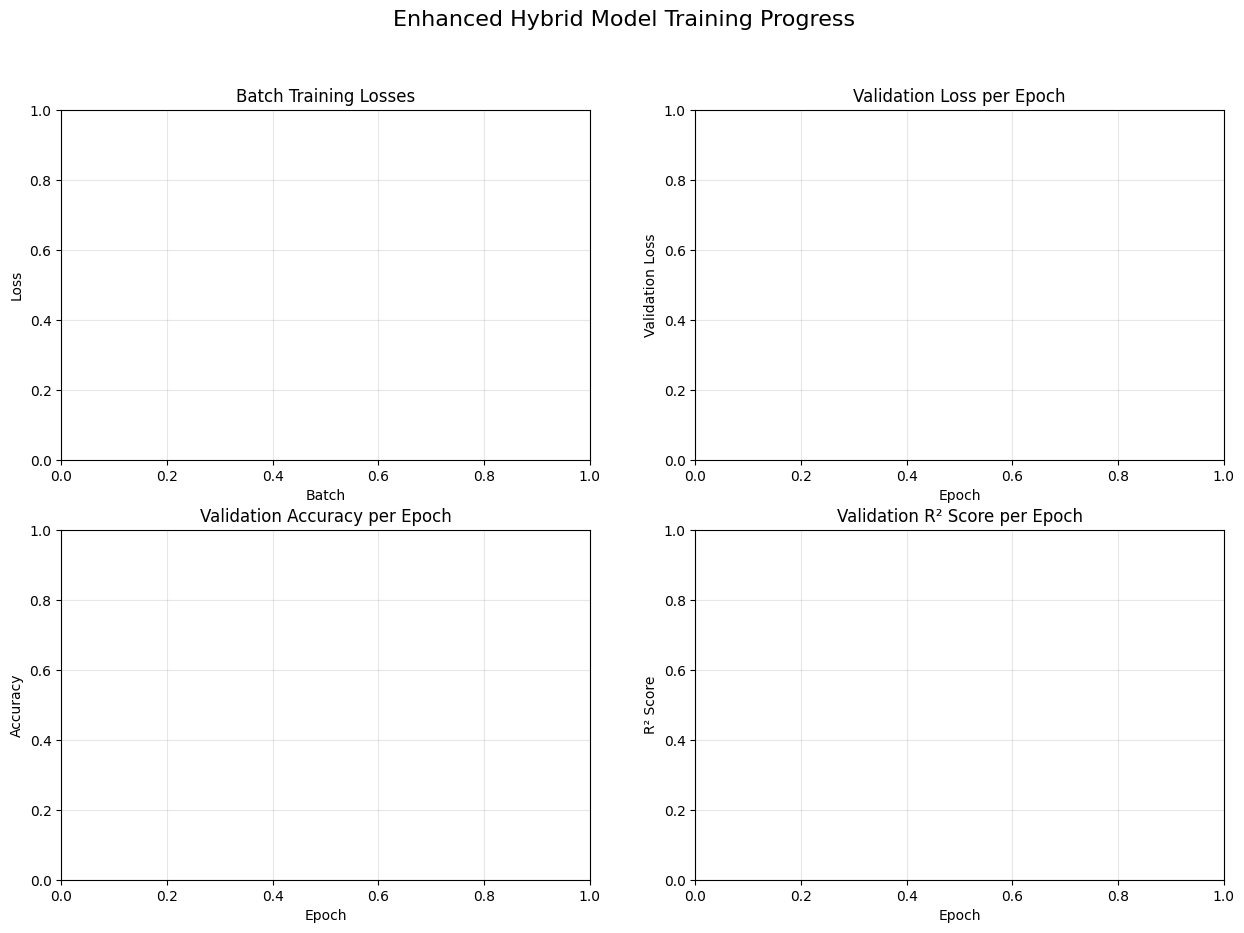

Starting enhanced hybrid model training for 100 epochs...
Output directory: enhanced_hybrid_training_20250723_103707
Classifier enabled: True, Regressor enabled: True
  Running validation...

  Epoch 1/100 Summary (6.9s):
  Train Loss: 2.385921 | Val Loss: 2.612368
  Class Loss: 1.242294 | Reg Loss: 1.143627
  Validation Accuracy: 0.4000 (40.00%)
  Validation R²: -0.1344 | MAE: 2.1348 | RMSE: 2.8215
NEW BEST MODEL SAVED! Path: enhanced_hybrid_training_20250723_103707/complete_model_epoch_1.pth
Plot saved as enhanced_hybrid_training_20250723_103707/best_model_epoch_1_plot.png
  Running validation...

  Epoch 2/100 Summary (0.6s):
  Train Loss: 1.663701 | Val Loss: 2.101433
  Class Loss: 0.692256 | Reg Loss: 0.971445
  Validation Accuracy: 0.4250 (42.50%)
  Validation R²: 0.2070 | MAE: 1.9113 | RMSE: 2.3591
NEW BEST MODEL SAVED! Path: enhanced_hybrid_training_20250723_103707/complete_model_epoch_2.pth
Plot saved as enhanced_hybrid_training_20250723_103707/best_model_epoch_2_plot.png
  Ru

Traceback (most recent call last):
  File "/var/folders/93/fpn59tk94sv7p8rsxztxw67m0000gn/T/ipykernel_53114/3651554909.py", line 1946, in <module>
    f.write(f"  Learning Rate: {config.learning_rate}\n")
                                ^^^^^^^^^^^^^^^^^^^^
AttributeError: 'TrainingConfig' object has no attribute 'learning_rate'


In [22]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import os
import json
import time
from datetime import datetime
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, classification_report
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Import your existing tools
from tools import TrainingConfig, load_multi_dataset_with_rewards_separate_stratification, load_ibw, compute_reward_with_top_features

def get_device():
    """Get the best available device in order: MPS -> CUDA -> CPU"""
    if torch.backends.mps.is_available():
        return torch.device('mps')
    elif torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')

class EnhancedHybridModel(nn.Module):
    """
    Enhanced hybrid model with both classification and regression capabilities
    """
    def __init__(self, input_size=None, hidden_sizes=[512, 256, 128], 
                 num_classes=5, dropout_rate=0.2, use_batch_norm=True,
                 activation='relu', target_mean=0.0, target_std=1.0,
                 enable_classifier=True, enable_regressor=True, device=None):
        super(EnhancedHybridModel, self).__init__()
        
        self.device = device if device is not None else get_device()
        self.num_classes = num_classes
        self.use_batch_norm = use_batch_norm
        self.enable_classifier = enable_classifier
        self.enable_regressor = enable_regressor
        
        # Store target statistics for denormalization
        self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # Shared CNN backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(6, 64, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(64) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256) if use_batch_norm else nn.Identity(),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        backbone_output_size = 256
        
        # Determine activation function
        if activation == 'relu':
            self.activation = nn.ReLU(inplace=True)
        elif activation == 'leaky_relu':
            self.activation = nn.LeakyReLU(0.2, inplace=True)
        elif activation == 'elu':
            self.activation = nn.ELU(inplace=True)
        else:
            self.activation = nn.ReLU(inplace=True)
        
        # Classification head
        if enable_classifier:
            classifier_layers = []
            prev_size = backbone_output_size
            
            for hidden_size in hidden_sizes:
                classifier_layers.extend([
                    nn.Linear(prev_size, hidden_size),
                    nn.BatchNorm1d(hidden_size) if use_batch_norm else nn.Identity(),
                    self.activation,
                    nn.Dropout(dropout_rate)
                ])
                prev_size = hidden_size
            
            classifier_layers.append(nn.Linear(prev_size, num_classes))
            self.classifier = nn.Sequential(*classifier_layers)
        else:
            self.classifier = None
        
        # Regression head
        if enable_regressor:
            regressor_layers = []
            prev_size = backbone_output_size
            
            for hidden_size in hidden_sizes:
                regressor_layers.extend([
                    nn.Linear(prev_size, hidden_size),
                    nn.BatchNorm1d(hidden_size) if use_batch_norm else nn.Identity(),
                    self.activation,
                    nn.Dropout(dropout_rate)
                ])
                prev_size = hidden_size
            
            # Final regression output with NO activation
            regressor_layers.append(nn.Linear(prev_size, 1))
            self.regressor = nn.Sequential(*regressor_layers)
        else:
            self.regressor = None
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with Xavier/He initialization"""
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Conv2d):
            nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)
    
    def forward(self, x, return_features=False, denormalize_regression=True):
        """Forward pass through the network"""
        # Extract shared features
        features = self.backbone(x)
        features = features.view(features.size(0), -1)  # Flatten
        
        outputs = {}
        
        # Classification output
        if self.classifier is not None:
            class_pred = self.classifier(features)
            outputs['classification'] = class_pred
        
        # Regression output
        if self.regressor is not None:
            reward_pred = self.regressor(features)
            
            # Denormalize predictions to original scale if requested
            if denormalize_regression and hasattr(self, 'target_mean') and hasattr(self, 'target_std'):
                reward_pred = reward_pred * self.target_std + self.target_mean
            
            outputs['regression'] = reward_pred
        
        if return_features:
            outputs['features'] = features
        
        return outputs
    
    def update_target_stats(self, target_mean, target_std):
        """Update target statistics for proper denormalization"""
        self.target_mean = torch.tensor(target_mean, dtype=torch.float32, device=self.target_mean.device)
        self.target_std = torch.tensor(target_std, dtype=torch.float32, device=self.target_std.device)


class EnhancedHybridDataset(Dataset):
    """Enhanced dataset for hybrid training"""
    def __init__(self, ibw_files, labels=None, rewards=None, scan_indices=None,
                 compute_rewards=False, use_augmentation=False,
                 reward_weights=None, normalize_targets=True):
        
        self.ibw_files = ibw_files
        self.labels = labels if labels is not None else [0] * len(ibw_files)
        self.rewards = rewards if rewards is not None else [0.0] * len(ibw_files)
        self.scan_indices = scan_indices if scan_indices is not None else list(range(len(ibw_files)))
        self.compute_rewards = compute_rewards
        self.use_augmentation = use_augmentation
        self.reward_weights = reward_weights
        self.normalize_targets = normalize_targets
        
        # Cache for IBW data
        self.ibw_cache = {}

        if compute_rewards:
            print("Computing rewards for dataset...")
            self.rewards = []
            for i, file_path in enumerate(ibw_files):
                try:
                    ibw_data = load_ibw(file_path)
                    reward = compute_reward_with_top_features(
                        ibw_data, scan_index=self.scan_indices[i], weights=self.reward_weights)
                    self.rewards.append(float(reward))
                except Exception as e:
                    print(f"Error computing reward for {file_path}: {e}")
                    self.rewards.append(0.0)
        
        # Compute target statistics for normalization
        if normalize_targets and len(self.rewards) > 0:
            rewards_array = np.array(self.rewards)
            self.target_mean = np.mean(rewards_array)
            self.target_std = np.std(rewards_array)
            if self.target_std < 1e-8:
                self.target_std = 1.0
            
            print(f"Target statistics: mean={self.target_mean:.4f}, std={self.target_std:.4f}")
        else:
            self.target_mean = 0.0
            self.target_std = 1.0

    def __len__(self):
        return len(self.ibw_files)

    def __getitem__(self, idx):
        try:
            file_path = self.ibw_files[idx]

            # Load ibw data (with caching)
            if idx in self.ibw_cache:
                ibw_data = self.ibw_cache[idx]
            else:
                ibw_data = load_ibw(file_path)
                if len(self.ibw_files) < 1000:
                    self.ibw_cache[idx] = ibw_data

            ch_names = ibw_data.channels

            # Extract the 6 channels as numpy arrays
            amp_trace = ibw_data.data[ch_names.index('Amplitude (T)')]
            amp_retrace = ibw_data.data[ch_names.index('Amplitude (RT)')]
            phase_trace = ibw_data.data[ch_names.index('Phase (T)')]
            phase_retrace = ibw_data.data[ch_names.index('Phase (RT)')]
            height_trace = ibw_data.data[ch_names.index('Height (T)')]
            height_retrace = ibw_data.data[ch_names.index('Height (RT)')]

            # Stack channels: shape (6, H, W)
            input_np = np.stack([
                amp_trace, amp_retrace,
                phase_trace, phase_retrace,
                height_trace, height_retrace
            ], axis=0).astype(np.float32)

            # Robust normalization with clipping
            for i in range(input_np.shape[0]):
                channel = input_np[i]
                mean_val = np.mean(channel)
                std_val = np.std(channel)
                if std_val > 1e-8:
                    channel = np.clip(channel, mean_val - 3*std_val, mean_val + 3*std_val)
                    input_np[i] = (channel - mean_val) / (std_val + 1e-8)
                else:
                    input_np[i] = channel - mean_val

            input_tensor = torch.tensor(input_np, dtype=torch.float32)
            
            # Prepare labels and rewards
            label = torch.tensor(self.labels[idx], dtype=torch.long)
            raw_reward = float(self.rewards[idx])
            
            if self.normalize_targets:
                normalized_reward = (raw_reward - self.target_mean) / self.target_std
                reward = torch.tensor(normalized_reward, dtype=torch.float32)
            else:
                reward = torch.tensor(raw_reward, dtype=torch.float32)

            return input_tensor, label, reward, torch.tensor(raw_reward, dtype=torch.float32)

        except Exception as e:
            print(f"Error in __getitem__ at idx {idx}: {e}")
            dummy = torch.zeros(6, 256, 256, dtype=torch.float32)
            return dummy, torch.tensor(0, dtype=torch.long), torch.tensor(0.0, dtype=torch.float32), torch.tensor(0.0, dtype=torch.float32)


def enhanced_hybrid_collate_fn(batch):
    """Enhanced collate function for hybrid training"""
    try:
        inputs = []
        labels = []
        rewards = []
        raw_rewards = []
        
        for item in batch:
            if len(item) == 4:
                input_tensor, label, reward, raw_reward = item
                inputs.append(input_tensor)
                labels.append(label)
                rewards.append(reward)
                raw_rewards.append(raw_reward)
            else:
                print(f"Unexpected item format: {len(item)} elements")
                continue
        
        if len(inputs) == 0:
            raise ValueError("No valid items in batch")
        
        # Stack tensors
        inputs_batch = torch.stack(inputs)
        labels_batch = torch.stack(labels)
        rewards_batch = torch.stack(rewards)
        raw_rewards_batch = torch.stack(raw_rewards)
        
        return inputs_batch, labels_batch, rewards_batch, raw_rewards_batch
        
    except Exception as e:
        print(f"Error in collate function: {e}")
        raise


import time
import numpy as np
from collections import deque

class RealTimeHybridPlotter:
    """Enhanced real-time plotter for hybrid model training metrics with validation plotting"""
    
    def __init__(self, use_jupyter=True, window_size=100, update_frequency=1, scroll_size=1000):
        # Import matplotlib at the beginning, regardless of environment
        import matplotlib.pyplot as plt
        self.plt = plt  # Store reference for use in other methods
        
        self.use_jupyter = use_jupyter
        self.window_size = window_size
        self.update_frequency = update_frequency  # Update plot every N batches
        self.update_counter = 0
        
        # Storage for metrics
        self.batch_numbers = deque(maxlen=scroll_size)
        self.total_losses = deque(maxlen=scroll_size)
        self.class_losses = deque(maxlen=scroll_size)
        self.reward_losses = deque(maxlen=scroll_size)
        self.val_losses = []
        self.val_accuracies = []
        self.epoch_numbers = []
        
        # # NEW: Storage for validation batch metrics
        # self.val_batch_numbers = deque(maxlen=scroll_size)
        # self.val_batch_losses = deque(maxlen=scroll_size)
        # self.val_batch_accuracies = deque(maxlen=scroll_size)
        # self.current_val_epoch = 0
        # self.val_batch_counter = 0
        
        # Storage for running averages (smoother plotting)
        self.running_total_loss = deque(maxlen=10)
        self.running_class_loss = deque(maxlen=10)
        self.running_reward_loss = deque(maxlen=10)
        
        # Setup plotting
        if use_jupyter:
            plt.ion()  # Turn on interactive mode
            # Use a different backend that works better with Jupyter
            try:
                plt.switch_backend('module://ipykernel.pylab.backend_inline')
            except:
                # Fallback if backend switch fails
                pass
        else:
            plt.ion()
        
        # Create figure with better settings for real-time updates
        # MODIFIED: Changed to 4x2 grid to accommodate validation batch plot
        self.fig = plt.figure(figsize=(18, 16))
        self.fig.suptitle('Hybrid Model Training Progress (Real-Time)', fontsize=16, fontweight='bold')
        
        # Create subplots with better spacing
        gs = self.fig.add_gridspec(4, 2, hspace=0.35, wspace=0.3)
        self.ax1 = self.fig.add_subplot(gs[0, :])  # Full width for batch losses
        self.ax2 = self.fig.add_subplot(gs[1, 0])  # Validation loss
        self.ax3 = self.fig.add_subplot(gs[1, 1])  # Validation accuracy
        self.ax4 = self.fig.add_subplot(gs[2, :])  # Combined metrics

        # self.ax5 = self.fig.add_subplot(gs[3, :])  # Validation batch metrics
        
        # Initialize batch loss plot (main real-time plot)
        self.line_total, = self.ax1.plot([], [], 'b-', label='Total Loss', linewidth=2, alpha=0.8)
        self.line_class, = self.ax1.plot([], [], 'r-', label='Classification Loss', linewidth=2, alpha=0.8)
        self.line_reward, = self.ax1.plot([], [], 'g-', label='Reward Loss', linewidth=2, alpha=0.8)
        
        # Add smoothed lines
        self.line_total_smooth, = self.ax1.plot([], [], 'b--', label='Total (Smoothed)', linewidth=1, alpha=0.6)
        self.line_class_smooth, = self.ax1.plot([], [], 'r--', label='Class (Smoothed)', linewidth=1, alpha=0.6)
        self.line_reward_smooth, = self.ax1.plot([], [], 'g--', label='Reward (Smoothed)', linewidth=1, alpha=0.6)
        
        self.ax1.set_title('Training Losses - Real-Time (Per Batch)', fontweight='bold')
        self.ax1.set_xlabel('Batch Number')
        self.ax1.set_ylabel('Loss')
        self.ax1.legend(loc='upper right', fontsize=9)
        self.ax1.grid(True, alpha=0.3)
        self.ax1.set_yscale('log')  # Log scale often better for loss visualization
        
        # Validation loss plot
        self.line_val_loss, = self.ax2.plot([], [], 'purple', marker='o', linewidth=3, markersize=8)
        self.ax2.set_title('Validation Loss (Per Epoch)', fontweight='bold')
        self.ax2.set_xlabel('Epoch')
        self.ax2.set_ylabel('Validation Loss')
        self.ax2.grid(True, alpha=0.3)
        
        # Validation accuracy plot
        self.line_val_acc, = self.ax3.plot([], [], 'orange', marker='s', linewidth=3, markersize=8)
        self.ax3.set_title('Validation Accuracy (Per Epoch)', fontweight='bold')
        self.ax3.set_xlabel('Epoch')
        self.ax3.set_ylabel('Accuracy (%)')
        self.ax3.grid(True, alpha=0.3)
        
        # Combined epoch metrics with dual y-axis
        self.ax4_twin = self.ax4.twinx()
        self.line_epoch_loss, = self.ax4.plot([], [], 'purple', marker='o', linewidth=3, 
                                            markersize=8, label='Validation Loss')
        self.line_epoch_acc, = self.ax4_twin.plot([], [], 'orange', marker='s', linewidth=3, 
                                                markersize=8, label='Validation Accuracy')
        self.ax4.set_title('Validation Metrics - Combined View', fontweight='bold')
        self.ax4.set_xlabel('Epoch')
        self.ax4.set_ylabel('Validation Loss', color='purple', fontweight='bold')
        self.ax4_twin.set_ylabel('Validation Accuracy (%)', color='orange', fontweight='bold')
        self.ax4.tick_params(axis='y', labelcolor='purple')
        self.ax4_twin.tick_params(axis='y', labelcolor='orange')
        self.ax4.grid(True, alpha=0.3)
        
        # Add combined legend
        lines1, labels1 = self.ax4.get_legend_handles_labels()
        lines2, labels2 = self.ax4_twin.get_legend_handles_labels()
        self.ax4.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
        

        # self.ax5_twin = self.ax5.twinx()
        # self.line_val_batch_loss, = self.ax5.plot([], [], 'darkred', linewidth=2, alpha=0.8, label='Val Batch Loss')
        # self.line_val_batch_acc, = self.ax5_twin.plot([], [], 'darkgreen', linewidth=2, alpha=0.8, label='Val Batch Accuracy')
        
        # # Add smoothed validation lines
        # self.line_val_batch_loss_smooth, = self.ax5.plot([], [], 'darkred', linewidth=1, alpha=0.5, linestyle='--', label='Val Loss (Smoothed)')
        # self.line_val_batch_acc_smooth, = self.ax5_twin.plot([], [], 'darkgreen', linewidth=1, alpha=0.5, linestyle='--', label='Val Acc (Smoothed)')
        
        # self.ax5.set_title('Validation Progress - Real-Time (Per Batch)', fontweight='bold')
        # self.ax5.set_xlabel('Validation Batch Number')
        # self.ax5.set_ylabel('Validation Loss', color='darkred', fontweight='bold')
        # self.ax5_twin.set_ylabel('Validation Accuracy (%)', color='darkgreen', fontweight='bold')
        # self.ax5.tick_params(axis='y', labelcolor='darkred')
        # self.ax5_twin.tick_params(axis='y', labelcolor='darkgreen')
        # self.ax5.grid(True, alpha=0.3)
        
        # # Add validation batch legend
        # lines5, labels5 = self.ax5.get_legend_handles_labels()
        # lines5_twin, labels5_twin = self.ax5_twin.get_legend_handles_labels()
        # self.ax5.legend(lines5 + lines5_twin, labels5 + labels5_twin, loc='upper left')
        
        # Add text box for current statistics
        self.stats_text = self.ax1.text(0.02, 0.98, '', transform=self.ax1.transAxes, 
                                       fontsize=10, verticalalignment='top',
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        

        # self.val_stats_text = self.ax5.text(0.02, 0.98, '', transform=self.ax5.transAxes, 
        #                                    fontsize=10, verticalalignment='top',
        #                                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
        # Show initial plot
        if use_jupyter:
            plt.show()
        else:
            plt.show(block=False)
            plt.draw()
        
        self.batch_counter = 0
        self.last_update_time = time.time()
        
        # Force initial draw
        self.fig.canvas.draw()
        self.fig.canvas.flush_events()
    
    def _calculate_smooth_values(self, values, window=10):
        """Calculate smoothed values using moving average"""
        if len(values) < window:
            return list(values)
        else:
            smoothed = []
            values_list = list(values)
            for i in range(len(values_list)):
                start_idx = max(0, i - window + 1)
                smoothed.append(np.mean(values_list[start_idx:i+1]))
            return smoothed
    
    def update_batch_metrics(self, total_loss, class_loss, reward_loss, force_update=False):
        """Update real-time batch metrics with improved performance"""
        self.batch_counter += 1
        self.update_counter += 1

        # Store metrics
        self.batch_numbers.append(self.batch_counter)
        self.total_losses.append(total_loss)
        self.class_losses.append(class_loss)
        self.reward_losses.append(reward_loss)
        
        # Store for running averages
        self.running_total_loss.append(total_loss)
        self.running_class_loss.append(class_loss)
        self.running_reward_loss.append(reward_loss)
        
        # Only update plot every N batches or if forced (to improve performance)
        if self.update_counter >= self.update_frequency or force_update:
            self.update_counter = 0
            self._update_batch_plot()
    
    def start_validation_epoch(self, epoch):
        """Call this when starting validation for a new epoch"""
        self.current_val_epoch = epoch
        self.val_batch_counter = 0
        print(f"Starting validation tracking for epoch {epoch}")
    
    def update_validation_batch(self, val_loss, val_accuracy, force_update=False):
        """Update validation metrics for each batch during validation"""
        self.val_batch_counter += 1
        
        # Store validation batch metrics
        self.val_batch_numbers.append(self.val_batch_counter)
        self.val_batch_losses.append(val_loss)
        self.val_batch_accuracies.append(val_accuracy * 100)  # Convert to percentage
        
        # Update plot every few batches or if forced
        if self.val_batch_counter % 5 == 0 or force_update:
            self._update_validation_batch_plot()
    
    def _update_validation_batch_plot(self):
        """Internal method to update the validation batch plot"""
        if len(self.val_batch_numbers) == 0:
            return
            
        batch_nums = list(self.val_batch_numbers)
        batch_losses = list(self.val_batch_losses)
        batch_accuracies = list(self.val_batch_accuracies)
        
        # Update main lines
        self.line_val_batch_loss.set_data(batch_nums, batch_losses)
        self.line_val_batch_acc.set_data(batch_nums, batch_accuracies)
        
        # Update smoothed lines
        if len(batch_nums) > 5:
            smooth_losses = self._calculate_smooth_values(batch_losses)
            smooth_accuracies = self._calculate_smooth_values(batch_accuracies)
            
            self.line_val_batch_loss_smooth.set_data(batch_nums, smooth_losses)
            self.line_val_batch_acc_smooth.set_data(batch_nums, smooth_accuracies)
        
        # Adjust axes dynamically
        if len(batch_nums) > 1:
            self.ax5.set_xlim(max(1, min(batch_nums)), max(batch_nums))
            self.ax5_twin.set_xlim(max(1, min(batch_nums)), max(batch_nums))
            
            # Set y-axis limits
            if batch_losses:
                loss_min, loss_max = min(batch_losses), max(batch_losses)
                loss_range = loss_max - loss_min
                self.ax5.set_ylim(loss_min - 0.1 * loss_range, loss_max + 0.1 * loss_range)
            
            if batch_accuracies:
                acc_min, acc_max = min(batch_accuracies), max(batch_accuracies)
                acc_range = acc_max - acc_min
                self.ax5_twin.set_ylim(max(0, acc_min - 0.1 * acc_range), min(100, acc_max + 0.1 * acc_range))
        
        # Update validation statistics text
        if len(batch_losses) > 0:
            current_val_stats = (
                f'Epoch {self.current_val_epoch} - Val Batch: {self.val_batch_counter}\n'
                f'Current - Loss: {batch_losses[-1]:.4f}, Acc: {batch_accuracies[-1]:.2f}%\n'
                f'Avg - Loss: {np.mean(batch_losses):.4f}, Acc: {np.mean(batch_accuracies):.2f}%'
            )
            self.val_stats_text.set_text(current_val_stats)
        
        # Force update
        self._force_plot_update()
    
    def _update_batch_plot(self):
        """Internal method to update the batch loss plot"""
        if len(self.batch_numbers) == 0:
            return
            
        batch_nums = list(self.batch_numbers)
        total_losses = list(self.total_losses)
        class_losses = list(self.class_losses)
        reward_losses = list(self.reward_losses)
        
        # Update main lines
        self.line_total.set_data(batch_nums, total_losses)
        self.line_class.set_data(batch_nums, class_losses)
        self.line_reward.set_data(batch_nums, reward_losses)
        
        # Update smoothed lines
        if len(batch_nums) > 5:  # Only show smoothed lines after some data
            smooth_total = self._calculate_smooth_values(total_losses)
            smooth_class = self._calculate_smooth_values(class_losses)
            smooth_reward = self._calculate_smooth_values(reward_losses)
            
            self.line_total_smooth.set_data(batch_nums, smooth_total)
            self.line_class_smooth.set_data(batch_nums, smooth_class)
            self.line_reward_smooth.set_data(batch_nums, smooth_reward)
        
        # Adjust axes dynamically
        if len(batch_nums) > 1:
            self.ax1.set_xlim(max(1, min(batch_nums)), max(batch_nums))
            
            # Use log scale limits
            all_losses = total_losses + class_losses + reward_losses
            min_loss = max(1e-6, min(all_losses))  # Avoid log(0)
            max_loss = max(all_losses)
            
            self.ax1.set_ylim(min_loss * 0.5, max_loss * 2.0)
        
        # Update statistics text
        if len(self.running_total_loss) > 0:
            current_stats = (
                f'Batch: {self.batch_counter}\n'
                f'Current - Total: {total_losses[-1]:.4f}, Class: {class_losses[-1]:.4f}, Reward: {reward_losses[-1]:.4f}\n'
                f'Avg (last 10) - Total: {np.mean(self.running_total_loss):.4f}, '
                f'Class: {np.mean(self.running_class_loss):.4f}, Reward: {np.mean(self.running_reward_loss):.4f}'
            )
            self.stats_text.set_text(current_stats)
        
        # Force update
        self._force_plot_update()
    
    def _force_plot_update(self):
        """Force the plot to update immediately"""
        try:
            if self.use_jupyter:
                # Jupyter-specific update method
                try:
                    from IPython.display import clear_output, display
                    clear_output(wait=True)
                    display(self.fig)
                except ImportError:
                    # Fallback for non-IPython environments
                    self.plt.draw()
                    self.plt.pause(0.001)
            else:
                # Standard matplotlib update
                self.fig.canvas.draw()
                self.fig.canvas.flush_events()
                self.plt.pause(0.001)  # Very small pause to allow GUI update
        except Exception as e:
            print(f"Warning: Plot update failed: {e}")
    
    def update_epoch_metrics(self, epoch, val_loss, val_accuracy):
        self.epoch_numbers.append(epoch)
        self.val_losses.append(val_loss)
        self.val_accuracies.append(val_accuracy)
        
        val_accuracy_pct = val_accuracy * 100
        val_accuracies_pct = [acc * 100 for acc in self.val_accuracies]

        # Update validation loss plot
        self.line_val_loss.set_data(self.epoch_numbers, self.val_losses)
        self.ax2.relim()
        self.ax2.autoscale_view()

        # Update validation accuracy plot
        self.line_val_acc.set_data(self.epoch_numbers, val_accuracies_pct)
        self.ax3.relim()
        self.ax3.autoscale_view()

        # Update combined plot
        self.line_epoch_loss.set_data(self.epoch_numbers, self.val_losses)
        self.line_epoch_acc.set_data(self.epoch_numbers, val_accuracies_pct)
        self.ax4.relim()
        self.ax4.autoscale_view()
        self.ax4_twin.relim()
        self.ax4_twin.autoscale_view()

        self._force_plot_update()
        print(f"  Epoch {epoch} - Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy_pct:.2f}%")
    
    def close(self):
        """Close the plot"""
        self.plt.close(self.fig)


def validate_enhanced_hybrid_model(model, val_dataloader, device, class_criterion, reg_criterion, 
                                 use_raw_targets=True, enable_classifier=True, enable_regressor=True):
    """Enhanced validation function for hybrid model"""
    model.eval()
    
    total_loss = 0.0
    class_loss_total = 0.0
    reg_loss_total = 0.0
    
    all_class_preds = []
    all_class_targets = []
    all_reg_preds = []
    all_reg_targets = []
    all_raw_reg_targets = []
    
    num_batches = 0
    
    with torch.no_grad():
        for batch_idx, batch_data in enumerate(val_dataloader):
            try:
                inputs, labels, rewards, raw_rewards = batch_data
                
                inputs = inputs.to(device)
                labels = labels.to(device)
                rewards = rewards.to(device)
                raw_rewards = raw_rewards.to(device)
                
                # Forward pass
                outputs = model(inputs, denormalize_regression=True)
                
                batch_loss = 0.0
                
                # Classification loss and metrics
                if enable_classifier and 'classification' in outputs:
                    class_pred = outputs['classification']
                    class_loss = class_criterion(class_pred, labels)
                    class_loss_total += class_loss.item()
                    batch_loss += class_loss
                    
                    # Store predictions for metrics
                    _, predicted = torch.max(class_pred, 1)
                    all_class_preds.extend(predicted.cpu().numpy())
                    all_class_targets.extend(labels.cpu().numpy())
                
                # Regression loss and metrics
                if enable_regressor and 'regression' in outputs:
                    reg_pred = outputs['regression'].squeeze()
                    
                    # Handle dimension mismatch
                    if reg_pred.dim() == 0:
                        reg_pred = reg_pred.unsqueeze(0)
                    if raw_rewards.dim() == 0:
                        raw_rewards = raw_rewards.unsqueeze(0)
                    if rewards.dim() == 0:
                        rewards = rewards.unsqueeze(0)
                    
                    min_len = min(len(reg_pred), len(rewards), len(raw_rewards))
                    reg_pred = reg_pred[:min_len]
                    rewards = rewards[:min_len]
                    raw_rewards = raw_rewards[:min_len]
                    
                    # Calculate loss using normalized targets
                    reg_outputs_norm = model(inputs, denormalize_regression=False)['regression'].squeeze()[:min_len]
                    reg_loss = reg_criterion(reg_outputs_norm, rewards)
                    reg_loss_total += reg_loss.item()
                    batch_loss += reg_loss
                    
                    # Store predictions for metrics (use raw scale)
                    if use_raw_targets:
                        all_reg_preds.extend(reg_pred.cpu().numpy().flatten())
                        all_reg_targets.extend(raw_rewards.cpu().numpy().flatten())
                    else:
                        all_reg_preds.extend(reg_pred.cpu().numpy().flatten())
                        all_reg_targets.extend(rewards.cpu().numpy().flatten())
                    
                    all_raw_reg_targets.extend(raw_rewards.cpu().numpy().flatten())
                
                total_loss += batch_loss.item()
                num_batches += 1
                
            except Exception as e:
                print(f"Error in validation batch {batch_idx}: {e}")
                continue
    
    if num_batches == 0:
        print("ERROR: No validation batches processed!")
        return float('inf'), 0.0, 0.0, float('inf'), float('inf')
    
    # Calculate metrics
    avg_val_loss = total_loss / num_batches
    avg_class_loss = class_loss_total / num_batches if enable_classifier else 0.0
    avg_reg_loss = reg_loss_total / num_batches if enable_regressor else 0.0
    
    # Classification metrics
    val_accuracy = 0.0
    if enable_classifier and len(all_class_preds) > 0:
        val_accuracy = accuracy_score(all_class_targets, all_class_preds)
    
    # Regression metrics
    val_r2 = 0.0
    val_mae = float('inf')
    val_rmse = float('inf')
    
    if enable_regressor and len(all_reg_preds) > 0:
        try:
            val_r2 = r2_score(all_reg_targets, all_reg_preds)
            val_mae = mean_absolute_error(all_reg_targets, all_reg_preds)
            val_rmse = np.sqrt(mean_squared_error(all_reg_targets, all_reg_preds))
        except Exception as e:
            print(f"Error calculating regression metrics: {e}")
    
    return avg_val_loss, val_accuracy, val_r2, val_mae, val_rmse


def build_optimizer(config, parameters):
    """Build optimizer from config"""
    optimizer_name = getattr(config, 'optimizer', 'adam').lower()
    learning_rate = getattr(config, 'learning_rate', 0.001)
    weight_decay = getattr(config, 'weight_decay', 1e-4)
    
    if optimizer_name == 'adam':
        return optim.Adam(parameters, lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'adamw':
        return optim.AdamW(parameters, lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == 'sgd':
        momentum = getattr(config, 'momentum', 0.9)
        return optim.SGD(parameters, lr=learning_rate, momentum=momentum, weight_decay=weight_decay)
    else:
        return optim.Adam(parameters, lr=learning_rate, weight_decay=weight_decay)


def build_scheduler(config, optimizer):
    """Build learning rate scheduler from config"""
    scheduler_name = getattr(config, 'scheduler', 'reducelronplateau').lower()
    
    if scheduler_name == 'reducelronplateau':
        patience = getattr(config, 'patience', 5)
        factor = getattr(config, 'factor', 0.5)
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=patience, factor=factor)
    elif scheduler_name == 'steplr':
        step_size = getattr(config, 'step_size', 10)
        gamma = getattr(config, 'gamma', 0.1)
        return optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    elif scheduler_name == 'cosineannealinglr':
        t_max = getattr(config, 't_max', 50)
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=t_max)
    else:
        return optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)


def save_model_components(model, output_dir, epoch, val_loss, val_accuracy, val_r2, train_losses, val_losses, val_accuracies, val_r2_scores, optimizer=None):
    """Save model components separately and together"""
    # Save complete model
    complete_model_path = os.path.join(output_dir, f'complete_model_epoch_{epoch}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
        'val_loss': val_loss,
        'val_accuracy': val_accuracy,
        'val_r2': val_r2,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'val_accuracies': val_accuracies,
        'val_r2_scores': val_r2_scores,
        'target_mean': model.target_mean.item(),
        'target_std': model.target_std.item(),
        'enable_classifier': model.enable_classifier,
        'enable_regressor': model.enable_regressor,
    }, complete_model_path)
    
    # Save classifier head separately if it exists
    if model.classifier is not None:
        classifier_path = os.path.join(output_dir, f'classifier_head_epoch_{epoch}.pth')
        torch.save({
            'classifier_state_dict': model.classifier.state_dict(),
            'backbone_state_dict': model.backbone.state_dict(),
            'num_classes': model.num_classes,
            'epoch': epoch,
            'val_accuracy': val_accuracy,
        }, classifier_path)
    
    # Save regressor head separately if it exists
    if model.regressor is not None:
        regressor_path = os.path.join(output_dir, f'regressor_head_epoch_{epoch}.pth')
        torch.save({
            'regressor_state_dict': model.regressor.state_dict(),
            'backbone_state_dict': model.backbone.state_dict(),
            'target_mean': model.target_mean.item(),
            'target_std': model.target_std.item(),
            'epoch': epoch,
            'val_r2': val_r2,
        }, regressor_path)
    
    return complete_model_path


def train_enhanced_hybrid_model(model, config, train_dataloader, val_dataloader, device, 
                                num_epochs=10, use_jupyter=True, output_dir='enhanced_hybrid_training',
                                enable_classifier=True, enable_regressor=True,
                                class_weight=1.0, reg_weight=1.0):
    """
    Enhanced training function for hybrid model with configurable heads
    """
    # Create output directory with timestamp
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_dir = f"{output_dir}_{timestamp}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Initialize enhanced plotter
    plotter = EnhancedHybridPlotter(
        use_jupyter=use_jupyter,
        window_size=400,
        update_frequency=5,
        scroll_size=400
    )
    
    # Setup loss functions
    class_criterion = nn.CrossEntropyLoss() if enable_classifier else None
    reg_criterion = nn.MSELoss() if enable_regressor else None
    
    # Build optimizer and scheduler
    optimizer = build_optimizer(config, model.parameters())
    scheduler = build_scheduler(config, optimizer)
    
    # Training tracking
    best_val_loss = float('inf')
    best_val_accuracy = 0.0
    best_val_r2 = -float('inf')
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_r2_scores = []
    val_mae_scores = []
    
    print(f"Starting enhanced hybrid model training for {num_epochs} epochs...")
    print(f"Output directory: {output_dir}")
    print(f"Classifier enabled: {enable_classifier}, Regressor enabled: {enable_regressor}")
    print("=" * 80)
    
    try:
        for epoch in range(num_epochs):
            start_time = time.time()
            
            # Training phase
            model.train()
            running_loss = 0.0
            running_class_loss = 0.0
            running_reg_loss = 0.0
            batch_count = 0
            
            for i, batch_data in enumerate(train_dataloader):
                try:
                    inputs, labels, rewards, raw_rewards = batch_data
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    rewards = rewards.to(device)
                    
                    optimizer.zero_grad()
                    
                    # Forward pass
                    outputs = model(inputs, denormalize_regression=False)  # Use normalized for training
                    
                    total_loss = 0.0
                    class_loss_item = 0.0
                    reg_loss_item = 0.0
                    
                    # Classification loss
                    if enable_classifier and 'classification' in outputs:
                        class_pred = outputs['classification']
                        class_loss = class_criterion(class_pred, labels)
                        total_loss += class_weight * class_loss
                        class_loss_item = class_loss.item()
                    
                    # Regression loss
                    if enable_regressor and 'regression' in outputs:
                        reg_pred = outputs['regression'].squeeze()
                        
                        # Handle dimension mismatch
                        if reg_pred.dim() == 0:
                            reg_pred = reg_pred.unsqueeze(0)
                        if rewards.dim() == 0:
                            rewards = rewards.unsqueeze(0)
                        
                        min_len = min(len(reg_pred), len(rewards))
                        reg_pred = reg_pred[:min_len]
                        rewards = rewards[:min_len]
                        
                        reg_loss = reg_criterion(reg_pred, rewards)
                        total_loss += reg_weight * reg_loss
                        reg_loss_item = reg_loss.item()
                    
                    # Backward pass
                    total_loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                    optimizer.step()
                    
                    # Update statistics
                    running_loss += total_loss.item()
                    running_class_loss += class_loss_item
                    running_reg_loss += reg_loss_item
                    batch_count += 1
                    
                    # Update plots
                    plotter.update_batch_metrics(
                        total_loss.item(),
                        class_loss_item,
                        reg_loss_item
                    )
                    
                    # Print progress
                    if (i + 1) % 50 == 0:
                        avg_loss = running_loss / batch_count
                        avg_class = running_class_loss / batch_count
                        avg_reg = running_reg_loss / batch_count
                        
                        print(f"  Epoch [{epoch+1}/{num_epochs}] Batch [{i+1}/{len(train_dataloader)}] - "
                              f"Loss: {total_loss.item():.4f} | Avg: {avg_loss:.4f} "
                              f"(Class: {avg_class:.4f}, Reg: {avg_reg:.4f})")
                
                except Exception as e:
                    print(f"Error in training batch {i}: {e}")
                    continue
            
            # Force plot update at end of epoch
            if batch_count > 0:
                plotter.update_batch_metrics(
                    total_loss.item(), class_loss_item, reg_loss_item, force_update=True
                )
            
            # Validation phase
            print(f"  Running validation...")
            val_loss, val_accuracy, val_r2, val_mae, val_rmse = validate_enhanced_hybrid_model(
                model, val_dataloader, device, class_criterion, reg_criterion,
                use_raw_targets=True, enable_classifier=enable_classifier, enable_regressor=enable_regressor
            )
            
            # Learning rate scheduling
            if hasattr(scheduler, 'step'):
                if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                    scheduler.step(val_loss)
                else:
                    scheduler.step()
            
            # Update tracking lists
            if batch_count > 0:
                avg_train_loss = running_loss / batch_count
                avg_class_loss = running_class_loss / batch_count
                avg_reg_loss = running_reg_loss / batch_count
                
                train_losses.append(avg_train_loss)
                val_losses.append(val_loss)
                val_accuracies.append(val_accuracy)
                val_r2_scores.append(val_r2)
                val_mae_scores.append(val_mae)
                
                # Update epoch plots
                plotter.update_epoch_metrics(epoch + 1, val_loss, val_accuracy, val_r2, val_mae)
                
                # Print epoch summary
                epoch_time = time.time() - start_time
                print(f"\n  Epoch {epoch+1}/{num_epochs} Summary ({epoch_time:.1f}s):")
                print(f"  Train Loss: {avg_train_loss:.6f} | Val Loss: {val_loss:.6f}")
                print(f"  Class Loss: {avg_class_loss:.6f} | Reg Loss: {avg_reg_loss:.6f}")
                if enable_classifier:
                    print(f"  Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
                if enable_regressor:
                    print(f"  Validation R²: {val_r2:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")
                
                # Save best model based on combined criteria
                is_best = False
                if enable_classifier and enable_regressor:
                    # Combined metric: accuracy + normalized R²
                    combined_score = val_accuracy + max(0, val_r2) / 2
                    if not hasattr(train_enhanced_hybrid_model, 'best_combined_score'):
                        train_enhanced_hybrid_model.best_combined_score = -float('inf')
                    if combined_score > train_enhanced_hybrid_model.best_combined_score:
                        train_enhanced_hybrid_model.best_combined_score = combined_score
                        is_best = True
                elif enable_classifier:
                    if val_accuracy > best_val_accuracy:
                        best_val_accuracy = val_accuracy
                        is_best = True
                elif enable_regressor:
                    if val_r2 > best_val_r2:
                        best_val_r2 = val_r2
                        is_best = True
                
                if is_best:
                    best_val_loss = val_loss
                    
                    # Save model components
                    best_model_path = save_model_components(
                        model, output_dir, epoch + 1, val_loss, val_accuracy, val_r2,
                        train_losses, val_losses, val_accuracies, val_r2_scores, optimizer
                    )
                    
                    print(f"NEW BEST MODEL SAVED! Path: {best_model_path}")
                    
                    # Save training plot
                    plotter.save_plot(os.path.join(output_dir, f'best_model_epoch_{epoch+1}_plot.png'))
                
                print("=" * 80)
    
    except KeyboardInterrupt:
        print("\nTraining interrupted by user")
        plotter.save_plot(os.path.join(output_dir, 'interrupted_training.png'))
    except Exception as e:
        print(f"Error during training: {e}")
        plotter.save_plot(os.path.join(output_dir, 'error_training.png'))
        raise
    finally:
        # Save final plot
        plotter.save_plot(os.path.join(output_dir, 'final_training_progress.png'))
        
        # Save training statistics
        stats = {
            'train_losses': train_losses,
            'val_losses': val_losses,
            'val_accuracies': val_accuracies,
            'val_r2_scores': val_r2_scores,
            'val_mae_scores': val_mae_scores,
            'best_val_loss': best_val_loss,
            'best_val_accuracy': best_val_accuracy,
            'best_val_r2': best_val_r2,
            'config': vars(config) if hasattr(config, '__dict__') else str(config),
            'enable_classifier': enable_classifier,
            'enable_regressor': enable_regressor,
        }
        
        with open(os.path.join(output_dir, 'training_stats.json'), 'w') as f:
            json.dump(stats, f, indent=2, default=str)
    
    print(f"\nTraining completed. Results saved in: {output_dir}")
    print(f"Best validation loss: {best_val_loss:.6f}")
    if enable_classifier:
        print(f"Best validation accuracy: {best_val_accuracy:.4f} ({best_val_accuracy*100:.2f}%)")
    if enable_regressor:
        print(f"Best validation R²: {best_val_r2:.4f}")
    
    return train_losses, val_losses, val_accuracies, val_r2_scores, plotter, optimizer, output_dir


def load_enhanced_hybrid_model(model_path, device='cpu', model_class=EnhancedHybridModel):
    """Load saved enhanced hybrid model"""
    checkpoint = torch.load(model_path, map_location=device)
    
    # Extract model configuration from checkpoint
    target_mean = checkpoint.get('target_mean', 0.0)
    target_std = checkpoint.get('target_std', 1.0)
    enable_classifier = checkpoint.get('enable_classifier', True)
    enable_regressor = checkpoint.get('enable_regressor', True)
    
    # Create model instance
    model = model_class(
        target_mean=target_mean,
        target_std=target_std,
        enable_classifier=enable_classifier,
        enable_regressor=enable_regressor
    )
    
    # Load state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    
    print(f"Model loaded from {model_path}")
    print(f"Epoch: {checkpoint.get('epoch', 'Unknown')}")
    print(f"Val Loss: {checkpoint.get('val_loss', 'Unknown')}")
    print(f"Val Accuracy: {checkpoint.get('val_accuracy', 'Unknown')}")
    print(f"Val R²: {checkpoint.get('val_r2', 'Unknown')}")
    
    return model, checkpoint


def predict_with_enhanced_hybrid_model(model, dataloader, device, enable_classifier=True, enable_regressor=True):
    """Make predictions with enhanced hybrid model"""
    model.eval()
    
    predictions = {
        'classification': [],
        'regression': [],
        'ground_truth_labels': [],
        'ground_truth_rewards': [],
        'raw_rewards': []
    }
    
    with torch.no_grad():
        for batch_data in dataloader:
            inputs, labels, rewards, raw_rewards = batch_data
            inputs = inputs.to(device)
            
            outputs = model(inputs, denormalize_regression=True)
            
            # Store ground truth
            predictions['ground_truth_labels'].extend(labels.numpy())
            predictions['ground_truth_rewards'].extend(rewards.numpy())
            predictions['raw_rewards'].extend(raw_rewards.numpy())
            
            # Classification predictions
            if enable_classifier and 'classification' in outputs:
                class_pred = outputs['classification']
                _, predicted = torch.max(class_pred, 1)
                predictions['classification'].extend(predicted.cpu().numpy())
            
            # Regression predictions
            if enable_regressor and 'regression' in outputs:
                reg_pred = outputs['regression'].squeeze()
                predictions['regression'].extend(reg_pred.cpu().numpy().flatten())
    
    return predictions


def create_enhanced_prediction_plots(predictions, output_dir, epoch=None, enable_classifier=True, enable_regressor=True):
    """Create enhanced prediction vs ground truth plots"""
    
    if enable_classifier and enable_regressor:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Classification plot
        if len(predictions['classification']) > 0:
            axes[0].scatter(predictions['ground_truth_labels'], predictions['classification'], alpha=0.6)
            max_class = max(max(predictions['ground_truth_labels']), max(predictions['classification']))
            axes[0].plot([0, max_class], [0, max_class], 'r--', label='Perfect Prediction')
            axes[0].set_xlabel('Ground Truth Labels')
            axes[0].set_ylabel('Predicted Labels')
            axes[0].set_title('Classification: Predicted vs Ground Truth')
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)
            
            # Calculate accuracy
            acc = accuracy_score(predictions['ground_truth_labels'], predictions['classification'])
            axes[0].text(0.05, 0.95, f'Accuracy: {acc:.3f}', transform=axes[0].transAxes, 
                        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        # Regression plot
        if len(predictions['regression']) > 0:
            axes[1].scatter(predictions['raw_rewards'], predictions['regression'], alpha=0.6)
            min_val = min(min(predictions['raw_rewards']), min(predictions['regression']))
            max_val = max(max(predictions['raw_rewards']), max(predictions['regression']))
            axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
            axes[1].set_xlabel('Ground Truth Rewards')
            axes[1].set_ylabel('Predicted Rewards')
            axes[1].set_title('Regression: Predicted vs Ground Truth')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
            
            # Calculate R²
            r2 = r2_score(predictions['raw_rewards'], predictions['regression'])
            mae = mean_absolute_error(predictions['raw_rewards'], predictions['regression'])
            axes[1].text(0.05, 0.95, f'R²: {r2:.3f}\nMAE: {mae:.3f}', transform=axes[1].transAxes,
                        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
        
    elif enable_classifier:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.scatter(predictions['ground_truth_labels'], predictions['classification'], alpha=0.6)
        max_class = max(max(predictions['ground_truth_labels']), max(predictions['classification']))
        ax.plot([0, max_class], [0, max_class], 'r--', label='Perfect Prediction')
        ax.set_xlabel('Ground Truth Labels')
        ax.set_ylabel('Predicted Labels')
        ax.set_title('Classification: Predicted vs Ground Truth')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        acc = accuracy_score(predictions['ground_truth_labels'], predictions['classification'])
        ax.text(0.05, 0.95, f'Accuracy: {acc:.3f}', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
    elif enable_regressor:
        fig, ax = plt.subplots(1, 1, figsize=(8, 6))
        ax.scatter(predictions['raw_rewards'], predictions['regression'], alpha=0.6)
        min_val = min(min(predictions['raw_rewards']), min(predictions['regression']))
        max_val = max(max(predictions['raw_rewards']), max(predictions['regression']))
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
        ax.set_xlabel('Ground Truth Rewards')
        ax.set_ylabel('Predicted Rewards')
        ax.set_title('Regression: Predicted vs Ground Truth')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        r2 = r2_score(predictions['raw_rewards'], predictions['regression'])
        mae = mean_absolute_error(predictions['raw_rewards'], predictions['regression'])
        ax.text(0.05, 0.95, f'R²: {r2:.3f}\nMAE: {mae:.3f}', transform=ax.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Save plot
    filename = f'predictions_epoch_{epoch}.png' if epoch else 'predictions.png'
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Prediction plot saved as {filepath}")
    
    return filepath

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, r2_score, mean_absolute_error, mean_squared_error
import torch
from torch.utils.data import DataLoader
import pandas as pd
from collections import defaultdict

def load_complete_dataset_for_prediction(base_folder, dataset_folders, reward_weights, num_classes=5):
    """Load complete dataset for comprehensive prediction visualization"""
    print(f"Loading complete dataset from {base_folder}")
    print(f"Dataset folders: {dataset_folders}")
    
    # Use your existing data loading function
    all_files, all_labels, all_rewards, dataset_info = load_multi_dataset_with_rewards_separate_stratification(
        [base_folder],
        dataset_folders, 
        reward_weights=reward_weights,
        labeling_method='stratified',
        num_classes=num_classes
    )
    
    print(f"Complete dataset loaded: {len(all_files)} files")
    return all_files, all_labels, all_rewards, dataset_info

def predict_complete_dataset(model, all_files, all_labels, all_rewards, reward_weights, device, batch_size=16):
    """Make predictions on complete dataset"""
    # Create dataset
    dataset = EnhancedHybridDataset(
        all_files, all_labels, all_rewards, list(range(len(all_files))),
        compute_rewards=False,
        reward_weights=reward_weights,
        normalize_targets=True
    )
    
    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=False,
        collate_fn=enhanced_hybrid_collate_fn, num_workers=0
    )
    
    # Make predictions
    predictions = predict_with_enhanced_hybrid_model(
        model, dataloader, device,
        enable_classifier=model.enable_classifier,
        enable_regressor=model.enable_regressor
    )
    
    return predictions, dataset

def create_comprehensive_prediction_grids(predictions, all_files, dataset_info, output_dir, 
                                        enable_classifier=True, enable_regressor=True, 
                                        grid_size=(10, 10)):
    """Create comprehensive prediction visualization grids"""
    
    # Create output directory for grids
    grid_dir = os.path.join(output_dir, 'prediction_grids')
    os.makedirs(grid_dir, exist_ok=True)
    
    # Organize data by dataset
    dataset_predictions = defaultdict(lambda: {
        'files': [], 'gt_labels': [], 'gt_rewards': [], 
        'pred_labels': [], 'pred_rewards': [], 'indices': []
    })
    
    # Group predictions by dataset
    for i, file_path in enumerate(all_files):
        dataset_name = None
        for name in dataset_info.keys():
            if name in file_path:
                dataset_name = name
                break
        if dataset_name is None:
            dataset_name = 'unknown'
            
        dataset_predictions[dataset_name]['files'].append(file_path)
        dataset_predictions[dataset_name]['gt_labels'].append(predictions['ground_truth_labels'][i])
        dataset_predictions[dataset_name]['gt_rewards'].append(predictions['raw_rewards'][i])
        dataset_predictions[dataset_name]['indices'].append(i)
        
        if enable_classifier and len(predictions['classification']) > 0:
            dataset_predictions[dataset_name]['pred_labels'].append(predictions['classification'][i])
        if enable_regressor and len(predictions['regression']) > 0:
            dataset_predictions[dataset_name]['pred_rewards'].append(predictions['regression'][i])
    
    # Create grids for each dataset
    all_grid_paths = []
    
    for dataset_name, data in dataset_predictions.items():
        print(f"Creating grids for dataset: {dataset_name} ({len(data['files'])} files)")
        
        if len(data['files']) == 0:
            continue
            
        # Calculate grid dimensions
        n_samples = len(data['files'])
        grid_rows = min(grid_size[0], int(np.ceil(np.sqrt(n_samples))))
        grid_cols = min(grid_size[1], int(np.ceil(n_samples / grid_rows)))
        
        # Create different visualization types
        grid_types = []
        
        if enable_classifier:
            grid_types.extend(['ground_truth_labels', 'predicted_labels'])
        if enable_regressor:
            grid_types.extend(['ground_truth_rewards', 'predicted_rewards'])
        if enable_classifier and enable_regressor:
            grid_types.extend(['classification_accuracy', 'regression_error'])
        
        for grid_type in grid_types:
            fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(grid_cols*3, grid_rows*3))
            if grid_rows == 1:
                axes = axes.reshape(1, -1)
            elif grid_cols == 1:
                axes = axes.reshape(-1, 1)
            
            fig.suptitle(f'{dataset_name} - {grid_type.replace("_", " ").title()}', fontsize=16, y=0.98)
            
            # Plot each sample
            for idx in range(min(n_samples, grid_rows * grid_cols)):
                row = idx // grid_cols
                col = idx % grid_cols
                ax = axes[row, col]
                
                file_path = data['files'][idx]
                filename = os.path.basename(file_path)
                
                # Determine what to visualize
                if grid_type == 'ground_truth_labels':
                    value = data['gt_labels'][idx]
                    color = plt.cm.tab10(value / 10.0)
                    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
                    ax.text(0.5, 0.5, f'GT: {value}', ha='center', va='center', fontweight='bold')
                    
                elif grid_type == 'predicted_labels' and len(data['pred_labels']) > idx:
                    value = data['pred_labels'][idx]
                    color = plt.cm.tab10(value / 10.0)
                    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
                    ax.text(0.5, 0.5, f'Pred: {value}', ha='center', va='center', fontweight='bold')
                    
                elif grid_type == 'ground_truth_rewards':
                    value = data['gt_rewards'][idx]
                    normalized_value = (value - min(data['gt_rewards'])) / (max(data['gt_rewards']) - min(data['gt_rewards']) + 1e-8)
                    color = plt.cm.viridis(normalized_value)
                    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
                    ax.text(0.5, 0.5, f'GT: {value:.2f}', ha='center', va='center', fontweight='bold', color='white')
                    
                elif grid_type == 'predicted_rewards' and len(data['pred_rewards']) > idx:
                    value = data['pred_rewards'][idx]
                    all_pred_rewards = [r for r in data['pred_rewards'] if r is not None]
                    if len(all_pred_rewards) > 0:
                        normalized_value = (value - min(all_pred_rewards)) / (max(all_pred_rewards) - min(all_pred_rewards) + 1e-8)
                        color = plt.cm.viridis(normalized_value)
                        ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
                        ax.text(0.5, 0.5, f'Pred: {value:.2f}', ha='center', va='center', fontweight='bold', color='white')
                    
                elif grid_type == 'classification_accuracy' and len(data['pred_labels']) > idx:
                    gt_label = data['gt_labels'][idx]
                    pred_label = data['pred_labels'][idx]
                    is_correct = gt_label == pred_label
                    color = 'green' if is_correct else 'red'
                    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color, alpha=0.7))
                    ax.text(0.5, 0.7, f'GT: {gt_label}', ha='center', va='center', fontweight='bold')
                    ax.text(0.5, 0.3, f'Pred: {pred_label}', ha='center', va='center', fontweight='bold')
                    ax.text(0.5, 0.1, '✓' if is_correct else '✗', ha='center', va='center', fontsize=20)
                    
                elif grid_type == 'regression_error' and len(data['pred_rewards']) > idx:
                    gt_reward = data['gt_rewards'][idx]
                    pred_reward = data['pred_rewards'][idx]
                    error = abs(gt_reward - pred_reward)
                    max_error = max([abs(data['gt_rewards'][i] - data['pred_rewards'][i]) 
                                   for i in range(len(data['pred_rewards'])) if data['pred_rewards'][i] is not None])
                    normalized_error = error / (max_error + 1e-8)
                    color = plt.cm.Reds(normalized_error)
                    ax.add_patch(plt.Rectangle((0, 0), 1, 1, color=color))
                    ax.text(0.5, 0.7, f'GT: {gt_reward:.2f}', ha='center', va='center', fontweight='bold')
                    ax.text(0.5, 0.5, f'Pred: {pred_reward:.2f}', ha='center', va='center', fontweight='bold')
                    ax.text(0.5, 0.3, f'Err: {error:.2f}', ha='center', va='center', fontweight='bold')
                
                # Set title and remove axes
                ax.set_title(filename[:15] + '...' if len(filename) > 15 else filename, fontsize=8)
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.set_xticks([])
                ax.set_yticks([])
            
            # Hide unused subplots
            for idx in range(n_samples, grid_rows * grid_cols):
                row = idx // grid_cols
                col = idx % grid_cols
                axes[row, col].set_visible(False)
            
            plt.tight_layout()
            
            # Save grid
            grid_filename = f'{dataset_name}_{grid_type}_grid.png'
            grid_path = os.path.join(grid_dir, grid_filename)
            plt.savefig(grid_path, dpi=300, bbox_inches='tight')
            plt.close(fig)
            
            all_grid_paths.append(grid_path)
            print(f"  Saved: {grid_filename}")
    
    return all_grid_paths

def create_summary_statistics_plots(predictions, output_dir, enable_classifier=True, enable_regressor=True):
    """Create summary statistics and distribution plots"""
    
    stats_dir = os.path.join(output_dir, 'summary_stats')
    os.makedirs(stats_dir, exist_ok=True)
    
    # Classification statistics
    if enable_classifier and len(predictions['classification']) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Confusion matrix
        from sklearn.metrics import confusion_matrix
        cm = confusion_matrix(predictions['ground_truth_labels'], predictions['classification'])
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
        axes[0,0].set_title('Confusion Matrix')
        axes[0,0].set_xlabel('Predicted Labels')
        axes[0,0].set_ylabel('Ground Truth Labels')
        
        # Class distribution comparison
        unique_gt, counts_gt = np.unique(predictions['ground_truth_labels'], return_counts=True)
        unique_pred, counts_pred = np.unique(predictions['classification'], return_counts=True)
        
        x_pos = np.arange(len(unique_gt))
        width = 0.35
        
        axes[0,1].bar(x_pos - width/2, counts_gt, width, label='Ground Truth', alpha=0.7)
        axes[0,1].bar(x_pos + width/2, counts_pred, width, label='Predicted', alpha=0.7)
        axes[0,1].set_xlabel('Class')
        axes[0,1].set_ylabel('Count')
        axes[0,1].set_title('Class Distribution Comparison')
        axes[0,1].set_xticks(x_pos)
        axes[0,1].set_xticklabels(unique_gt)
        axes[0,1].legend()
        
        # Accuracy by class
        class_accuracies = []
        for class_id in unique_gt:
            mask = np.array(predictions['ground_truth_labels']) == class_id
            if np.sum(mask) > 0:
                class_acc = accuracy_score(
                    np.array(predictions['ground_truth_labels'])[mask],
                    np.array(predictions['classification'])[mask]
                )
                class_accuracies.append(class_acc)
            else:
                class_accuracies.append(0)
        
        axes[1,0].bar(unique_gt, class_accuracies)
        axes[1,0].set_xlabel('Class')
        axes[1,0].set_ylabel('Accuracy')
        axes[1,0].set_title('Per-Class Accuracy')
        axes[1,0].set_ylim(0, 1)
        
        # Overall metrics text
        overall_acc = accuracy_score(predictions['ground_truth_labels'], predictions['classification'])
        report = classification_report(predictions['ground_truth_labels'], predictions['classification'])
        
        axes[1,1].text(0.1, 0.9, f'Overall Accuracy: {overall_acc:.4f}', transform=axes[1,1].transAxes, fontsize=12)
        axes[1,1].text(0.1, 0.1, report, transform=axes[1,1].transAxes, fontsize=8, family='monospace')
        axes[1,1].set_xlim(0, 1)
        axes[1,1].set_ylim(0, 1)
        axes[1,1].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(stats_dir, 'classification_summary.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)
    
    # Regression statistics
    if enable_regressor and len(predictions['regression']) > 0:
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Scatter plot
        axes[0,0].scatter(predictions['raw_rewards'], predictions['regression'], alpha=0.6)
        min_val = min(min(predictions['raw_rewards']), min(predictions['regression']))
        max_val = max(max(predictions['raw_rewards']), max(predictions['regression']))
        axes[0,0].plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')
        axes[0,0].set_xlabel('Ground Truth Rewards')
        axes[0,0].set_ylabel('Predicted Rewards')
        axes[0,0].set_title('Regression: Predicted vs Ground Truth')
        axes[0,0].legend()
        axes[0,0].grid(True, alpha=0.3)
        
        # Residuals plot
        residuals = np.array(predictions['regression']) - np.array(predictions['raw_rewards'])
        axes[0,1].scatter(predictions['raw_rewards'], residuals, alpha=0.6)
        axes[0,1].axhline(y=0, color='r', linestyle='--')
        axes[0,1].set_xlabel('Ground Truth Rewards')
        axes[0,1].set_ylabel('Residuals')
        axes[0,1].set_title('Residuals Plot')
        axes[0,1].grid(True, alpha=0.3)
        
        # Distribution comparison
        axes[1,0].hist(predictions['raw_rewards'], bins=30, alpha=0.7, label='Ground Truth', density=True)
        axes[1,0].hist(predictions['regression'], bins=30, alpha=0.7, label='Predicted', density=True)
        axes[1,0].set_xlabel('Reward Values')
        axes[1,0].set_ylabel('Density')
        axes[1,0].set_title('Reward Distribution Comparison')
        axes[1,0].legend()
        
        # Metrics text
        r2 = r2_score(predictions['raw_rewards'], predictions['regression'])
        mae = mean_absolute_error(predictions['raw_rewards'], predictions['regression'])
        rmse = np.sqrt(mean_squared_error(predictions['raw_rewards'], predictions['regression']))
        
        metrics_text = f"""
        Regression Metrics:
        R² Score: {r2:.4f}
        MAE: {mae:.4f}
        RMSE: {rmse:.4f}
        
        Data Statistics:
        GT Mean: {np.mean(predictions['raw_rewards']):.4f}
        GT Std: {np.std(predictions['raw_rewards']):.4f}
        Pred Mean: {np.mean(predictions['regression']):.4f}
        Pred Std: {np.std(predictions['regression']):.4f}
        """
        
        axes[1,1].text(0.1, 0.5, metrics_text, transform=axes[1,1].transAxes, fontsize=12, family='monospace')
        axes[1,1].axis('off')
        
        plt.tight_layout()
        plt.savefig(os.path.join(stats_dir, 'regression_summary.png'), dpi=300, bbox_inches='tight')
        plt.close(fig)
    
    print(f"Summary statistics saved in: {stats_dir}")

def run_comprehensive_prediction_analysis(model, config, device, output_dir):
    """Run comprehensive prediction analysis on complete dataset"""
    
    print("\n" + "="*80)
    print("RUNNING COMPREHENSIVE PREDICTION ANALYSIS")
    print("="*80)
    
    try:
        # Load complete dataset
        base_folder = config.original_dataset['base_folder']
        dataset_folders = config.original_dataset['dataset_folders']
        reward_weights = config.augmented_dataset['reward_weights']
        
        all_files, all_labels, all_rewards, dataset_info = load_complete_dataset_for_prediction(
            base_folder, dataset_folders, reward_weights, config.num_classes
        )
        
        # Make predictions on complete dataset
        print("Making predictions on complete dataset...")
        predictions, dataset = predict_complete_dataset(
            model, all_files, all_labels, all_rewards, reward_weights, device
        )
        
        # Create comprehensive grids
        print("Creating comprehensive prediction grids...")
        grid_paths = create_comprehensive_prediction_grids(
            predictions, all_files, dataset_info, output_dir,
            enable_classifier=model.enable_classifier,
            enable_regressor=model.enable_regressor
        )
        
        # Create summary statistics
        print("Creating summary statistics...")
        create_summary_statistics_plots(
            predictions, output_dir,
            enable_classifier=model.enable_classifier,
            enable_regressor=model.enable_regressor
        )
        
        # Print overall metrics
        print("\n" + "="*60)
        print("COMPREHENSIVE ANALYSIS RESULTS")
        print("="*60)
        
        if model.enable_classifier and len(predictions['classification']) > 0:
            overall_acc = accuracy_score(predictions['ground_truth_labels'], predictions['classification'])
            print(f"Overall Classification Accuracy: {overall_acc:.4f} ({overall_acc*100:.2f}%)")
        
        if model.enable_regressor and len(predictions['regression']) > 0:
            r2 = r2_score(predictions['raw_rewards'], predictions['regression'])
            mae = mean_absolute_error(predictions['raw_rewards'], predictions['regression'])
            rmse = np.sqrt(mean_squared_error(predictions['raw_rewards'], predictions['regression']))
            print(f"Overall Regression R²: {r2:.4f}")
            print(f"Overall Regression MAE: {mae:.4f}")
            print(f"Overall Regression RMSE: {rmse:.4f}")
        
        print(f"\nTotal files analyzed: {len(all_files)}")
        print(f"Prediction grids saved: {len(grid_paths)}")
        print(f"All results saved in: {output_dir}")
        
        return predictions, dataset_info, grid_paths
        
    except Exception as e:
        print(f"Error during comprehensive analysis: {e}")
        import traceback
        traceback.print_exc()
        return None, None, None


# Main execution code
if __name__ == "__main__":
    import matplotlib.pyplot as plt

    # Set device
    device = torch.device('mps')
    print(f"Using device: {device}")
    
    # Create a default training configuration
    config = TrainingConfig(
        learning_rate=0.001,
        batch_size=16,
        num_epochs=20,
        optimizer='adamw',
        scheduler='reducelronplateau',
        weight_decay=1e-4,
        patience=5,
        factor=0.5,
    )
    
    print("Loading datasets...")
    
    # Load your datasets using the existing function
    try:
        if torch.cuda.is_available():
            device = torch.device('cuda')
            print("Using CUDA")
        elif hasattr(torch, 'has_mps') and torch.has_mps and torch.mps.is_available():
            device = torch.device('mps')
            print("Using MPS (Apple Silicon)")
        else:
            device = torch.device('cpu')
            print("Using CPU")

        # Load configuration
        config_path = 'config.yaml'
        config = TrainingConfig.from_yaml(config_path)
        
        base_folder = config.original_dataset['base_folder']
        dataset_folders = config.original_dataset['dataset_folders']
        
        print(f"\nLoading data from: {base_folder}")
        print(f"Dataset folders: {dataset_folders}")
        
        # Load data
        all_files, all_labels, all_rewards, dataset_info = load_multi_dataset_with_rewards_separate_stratification(
            [base_folder],
            dataset_folders, 
            reward_weights=config.augmented_dataset['reward_weights'],
            labeling_method='stratified',
            num_classes=config.num_classes
        )
        
        print(f"Dataset loaded successfully:")
        print(f"  Total files: {len(all_files)}")
        
    except Exception as e:
        print(f"Error loading dataset: {e}")
        print("Please ensure your dataset loading function is properly configured.")
        exit(1)
    
    # Create train/val split
    train_indices, val_indices = train_test_split(
        np.arange(len(all_files)),
        train_size=config.train_split_weight,
        stratify=all_labels,
        random_state=42
    )
    
    # Partition data
    train_files = [all_files[i] for i in train_indices]
    train_labels = [all_labels[i] for i in train_indices]
    train_rewards = [all_rewards[i] for i in train_indices]
    
    val_files = [all_files[i] for i in val_indices]
    val_labels = [all_labels[i] for i in val_indices]
    val_rewards = [all_rewards[i] for i in val_indices]

    print(f"  Train: {len(train_files)} files")
    print(f"  Val: {len(val_files)} files")

    reward_weights = config.augmented_dataset['reward_weights']

    # Create datasets
    train_dataset = EnhancedHybridDataset(
        train_files, train_labels, train_rewards, train_indices,
        compute_rewards=False,  # Already computed
        use_augmentation=True,
        reward_weights=reward_weights,
        normalize_targets=True
    )
    
    val_dataset = EnhancedHybridDataset(
        val_files, val_labels, val_rewards, val_indices,
        compute_rewards=False,
        reward_weights=reward_weights,
        normalize_targets=True
    )
    
    # Create data loaders
    train_dataloader = DataLoader(
        train_dataset, batch_size=config.training_batch_size, shuffle=True,
        collate_fn=enhanced_hybrid_collate_fn, num_workers=0
    )
    
    val_dataloader = DataLoader(
        val_dataset, batch_size=config.training_batch_size, shuffle=False,
        collate_fn=enhanced_hybrid_collate_fn, num_workers=0
    )
    
    # Create model
    model = EnhancedHybridModel(
        hidden_sizes=[512, 256, 128],
        num_classes=5,  # Adjust based on your classification problem
        dropout_rate=0.2,
        use_batch_norm=True,
        activation='relu',
        target_mean=train_dataset.target_mean,
        target_std=train_dataset.target_std,
        enable_classifier=True,  # Set to False to disable classification
        enable_regressor=True    # Set to False to disable regression
    ).to(device)
    
    print(f"Model created with {sum(p.numel() for p in model.parameters())} parameters")
    
    # Start training
    try:
        train_losses, val_losses, val_accuracies, val_r2_scores, plotter, optimizer, output_dir = train_enhanced_hybrid_model(
            model=model,
            config=config,
            train_dataloader=train_dataloader,
            val_dataloader=val_dataloader,
            device=device,
            num_epochs=config.num_epochs,
            use_jupyter=False,  # Set to True if running in Jupyter
            output_dir='enhanced_hybrid_training',
            enable_classifier=True,
            enable_regressor=True,
            class_weight=1.0,
            reg_weight=1.0
        )
        
        # Test the best model on validation set
        print("\n" + "="*80)
        print("Testing best model on validation set...")
        
        # Load best model
        best_model_files = [f for f in os.listdir(output_dir) if f.startswith('complete_model_epoch_')]
        if best_model_files:
            best_model_path = os.path.join(output_dir, sorted(best_model_files)[-1])
            model, checkpoint = load_enhanced_hybrid_model(best_model_path, device)
            
            # Make predictions on validation set
            val_predictions = predict_with_enhanced_hybrid_model(
                model, val_dataloader, device,
                enable_classifier=model.enable_classifier,
                enable_regressor=model.enable_regressor
            )
            
            # Create prediction plots for validation set
            create_enhanced_prediction_plots(
                val_predictions, output_dir, epoch='validation',
                enable_classifier=model.enable_classifier,
                enable_regressor=model.enable_regressor
            )
            
            # Print validation metrics
            if model.enable_classifier and len(val_predictions['classification']) > 0:
                val_acc = accuracy_score(val_predictions['ground_truth_labels'], val_predictions['classification'])
                print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")
                
                # Classification report
                print("\nValidation Classification Report:")
                print(classification_report(val_predictions['ground_truth_labels'], val_predictions['classification']))
            
            if model.enable_regressor and len(val_predictions['regression']) > 0:
                val_r2 = r2_score(val_predictions['raw_rewards'], val_predictions['regression'])
                val_mae = mean_absolute_error(val_predictions['raw_rewards'], val_predictions['regression'])
                val_rmse = np.sqrt(mean_squared_error(val_predictions['raw_rewards'], val_predictions['regression']))
                
                print(f"Validation R²: {val_r2:.4f}")
                print(f"Validation MAE: {val_mae:.4f}")
                print(f"Validation RMSE: {val_rmse:.4f}")
        
        # ======================================================================
        # COMPREHENSIVE PREDICTION ANALYSIS ON COMPLETE DATASET
        # ======================================================================
        
        print("\n" + "="*80)
        print("STARTING COMPREHENSIVE PREDICTION ANALYSIS")
        print("="*80)
        
        # Run comprehensive analysis on the complete dataset
        comprehensive_predictions, dataset_info_analysis, grid_paths = run_comprehensive_prediction_analysis(
            model=model,
            config=config,
            device=device,
            output_dir=output_dir
        )
        
        if comprehensive_predictions is not None:
            print("\n" + "="*80)
            print("COMPREHENSIVE ANALYSIS COMPLETED SUCCESSFULLY!")
            print("="*80)
            
            # Print final summary
            total_files = len(comprehensive_predictions['ground_truth_labels'])
            print(f"\nFinal Analysis Summary:")
            print(f"  Total files analyzed: {total_files}")
            print(f"  Datasets analyzed: {list(dataset_info_analysis.keys()) if dataset_info_analysis else 'N/A'}")
            print(f"  Prediction grids created: {len(grid_paths) if grid_paths else 0}")
            
            if model.enable_classifier and len(comprehensive_predictions['classification']) > 0:
                final_acc = accuracy_score(comprehensive_predictions['ground_truth_labels'], comprehensive_predictions['classification'])
                print(f"  Overall Classification Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)")
            
            if model.enable_regressor and len(comprehensive_predictions['regression']) > 0:
                final_r2 = r2_score(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression'])
                final_mae = mean_absolute_error(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression'])
                final_rmse = np.sqrt(mean_squared_error(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression']))
                print(f"  Overall Regression R²: {final_r2:.4f}")
                print(f"  Overall Regression MAE: {final_mae:.4f}")
                print(f"  Overall Regression RMSE: {final_rmse:.4f}")
            
            # Print detailed breakdown by dataset
            if dataset_info_analysis:
                print(f"\nDataset Breakdown:")
                for dataset_name, info in dataset_info_analysis.items():
                    print(f"  {dataset_name}: {info.get('count', 'N/A')} files")
            
            print(f"\nAll comprehensive analysis results saved in:")
            print(f"  Main directory: {output_dir}")
            print(f"  Prediction grids: {os.path.join(output_dir, 'prediction_grids')}")
            print(f"  Summary statistics: {os.path.join(output_dir, 'summary_stats')}")
            
            # List all created grid files
            if grid_paths:
                print(f"\nCreated visualization grids:")
                for grid_path in grid_paths:
                    grid_filename = os.path.basename(grid_path)
                    print(f"    - {grid_filename}")
        
        else:
            print("\n" + "="*80)
            print("COMPREHENSIVE ANALYSIS FAILED - CHECK LOGS ABOVE")
            print("="*80)
        
        # ======================================================================
        # ADDITIONAL ANALYSIS OPTIONS
        # ======================================================================
        
        print("\n" + "="*80)
        print("ADDITIONAL ANALYSIS COMPLETED")
        print("="*80)
        
        # Create a detailed performance report
        report_path = os.path.join(output_dir, 'comprehensive_analysis_report.txt')
        with open(report_path, 'w') as f:
            f.write("="*80 + "\n")
            f.write("COMPREHENSIVE HYBRID MODEL ANALYSIS REPORT\n")
            f.write("="*80 + "\n\n")
            
            f.write(f"Model Configuration:\n")
            f.write(f"  Architecture: Enhanced Hybrid Model\n")
            f.write(f"  Hidden Sizes: [512, 256, 128]\n")
            f.write(f"  Number of Classes: {config.num_classes}\n")
            f.write(f"  Classifier Enabled: {model.enable_classifier}\n")
            f.write(f"  Regressor Enabled: {model.enable_regressor}\n")
            f.write(f"  Total Parameters: {sum(p.numel() for p in model.parameters())}\n\n")
            
            f.write(f"Training Configuration:\n")
            f.write(f"  Learning Rate: {config.learning_rate}\n")
            f.write(f"  Batch Size: {config.training_batch_size}\n")
            f.write(f"  Number of Epochs: {config.num_epochs}\n")
            f.write(f"  Optimizer: {config.optimizer}\n")
            f.write(f"  Scheduler: {config.scheduler}\n\n")
            
            f.write(f"Dataset Information:\n")
            f.write(f"  Base Folder: {base_folder}\n")
            f.write(f"  Dataset Folders: {dataset_folders}\n")
            f.write(f"  Total Files: {len(all_files)}\n")
            f.write(f"  Training Files: {len(train_files)}\n")
            f.write(f"  Validation Files: {len(val_files)}\n\n")
            
            if comprehensive_predictions:
                f.write(f"Comprehensive Analysis Results:\n")
                total_analyzed = len(comprehensive_predictions['ground_truth_labels'])
                f.write(f"  Total Files Analyzed: {total_analyzed}\n")
                
                if model.enable_classifier and len(comprehensive_predictions['classification']) > 0:
                    final_acc = accuracy_score(comprehensive_predictions['ground_truth_labels'], comprehensive_predictions['classification'])
                    f.write(f"  Overall Classification Accuracy: {final_acc:.4f} ({final_acc*100:.2f}%)\n")
                    
                    # Per-class accuracy
                    unique_classes = np.unique(comprehensive_predictions['ground_truth_labels'])
                    f.write(f"  Per-Class Accuracy:\n")
                    for class_id in unique_classes:
                        mask = np.array(comprehensive_predictions['ground_truth_labels']) == class_id
                        if np.sum(mask) > 0:
                            class_acc = accuracy_score(
                                np.array(comprehensive_predictions['ground_truth_labels'])[mask],
                                np.array(comprehensive_predictions['classification'])[mask]
                            )
                            class_count = np.sum(mask)
                            f.write(f"    Class {class_id}: {class_acc:.4f} ({class_count} samples)\n")
                
                if model.enable_regressor and len(comprehensive_predictions['regression']) > 0:
                    final_r2 = r2_score(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression'])
                    final_mae = mean_absolute_error(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression'])
                    final_rmse = np.sqrt(mean_squared_error(comprehensive_predictions['raw_rewards'], comprehensive_predictions['regression']))
                    f.write(f"  Overall Regression R²: {final_r2:.4f}\n")
                    f.write(f"  Overall Regression MAE: {final_mae:.4f}\n")
                    f.write(f"  Overall Regression RMSE: {final_rmse:.4f}\n")
                    
                    # Reward statistics
                    f.write(f"  Reward Statistics:\n")
                    f.write(f"    Ground Truth Mean: {np.mean(comprehensive_predictions['raw_rewards']):.4f}\n")
                    f.write(f"    Ground Truth Std: {np.std(comprehensive_predictions['raw_rewards']):.4f}\n")
                    f.write(f"    Predicted Mean: {np.mean(comprehensive_predictions['regression']):.4f}\n")
                    f.write(f"    Predicted Std: {np.std(comprehensive_predictions['regression']):.4f}\n")
                
                f.write(f"\nGenerated Visualizations:\n")
                if grid_paths:
                    for grid_path in grid_paths:
                        f.write(f"  - {os.path.basename(grid_path)}\n")
                
                f.write(f"\nOutput Directories:\n")
                f.write(f"  Main: {output_dir}\n")
                f.write(f"  Grids: {os.path.join(output_dir, 'prediction_grids')}\n")
                f.write(f"  Statistics: {os.path.join(output_dir, 'summary_stats')}\n")
        
        print(f"Detailed analysis report saved: {report_path}")
        
        print(f"\nTraining and comprehensive analysis completed successfully!")
        print(f"All results saved in: {output_dir}")
        
    except Exception as e:
        print(f"Training or analysis failed with error: {e}")
        import traceback
        traceback.print_exc()

# Outputs of the model predictions and grids are stored in the saved model folder generated
